Just merging all the years together to make a working set.

In [1]:
import pandas as pd
import os

folder_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Medicare"
save_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"

all_dfs = []

for year in range(2013, 2024):
    file_path = os.path.join(folder_path, f"{year} medicare.xlsx")
    if os.path.exists(file_path):
        df = pd.read_excel(file_path)
        df["Year"] = year
        all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)

working_file = os.path.join(save_path, "medicare_working_dataset.csv")
combined_df.to_csv(working_file, index=False)

sample_df = combined_df.sample(n=5000, random_state=1)
sample_file = os.path.join(save_path, "medicare_sample_dataset.csv")
sample_df.to_csv(sample_file, index=False)




KeyboardInterrupt: 

In [ ]:
import pandas as pd
import os

# paths
save_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"
working_file = os.path.join(save_path, "medicare_working_dataset.csv")

# load working dataset
df = pd.read_csv(working_file)

# quick structure checks
print(df.shape)
print(df.columns.tolist())

# basic missingness (top 15)
print((df.isna().mean().sort_values(ascending=False).head(15) * 100).round(2))

# key counts
print("years:", df["Year"].nunique())
print("hospitals (CCN):", df["Rndrng_Prvdr_CCN"].nunique())
print("drgs:", df["DRG_Cd"].nunique())
print("states:", df["Rndrng_Prvdr_State_Abrvtn"].nunique())

# outcome summaries
print(df["Avg_Submtd_Cvrd_Chrg"].describe())
print(df["Avg_Tot_Pymt_Amt"].describe())
print(df["Avg_Mdcr_Pymt_Amt"].describe())

# check duplicates on hospital x drg x year
k = ["Rndrng_Prvdr_CCN", "DRG_Cd", "Year"]
print("duplicate hospital-drg-year rows:", df.duplicated(k).sum())

# top DRGs by hospital coverage
top_drgs = (
    df.groupby("DRG_Desc")["Rndrng_Prvdr_CCN"]
      .nunique()
      .sort_values(ascending=False)
      .head(25)
)
print(top_drgs)

# top states by row count
top_states = df["Rndrng_Prvdr_State_Abrvtn"].value_counts().head(20)
print(top_states)


(1985253, 16)
['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_St', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'DRG_Cd', 'DRG_Desc', 'Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt', 'Year']
Rndrng_Prvdr_RUCA            0.05
Rndrng_Prvdr_RUCA_Desc       0.05
Rndrng_Prvdr_City            0.00
Rndrng_Prvdr_CCN             0.00
Rndrng_Prvdr_St              0.00
Rndrng_Prvdr_State_FIPS      0.00
Rndrng_Prvdr_Zip5            0.00
Rndrng_Prvdr_Org_Name        0.00
Rndrng_Prvdr_State_Abrvtn    0.00
DRG_Cd                       0.00
DRG_Desc                     0.00
Tot_Dschrgs                  0.00
Avg_Submtd_Cvrd_Chrg         0.00
Avg_Tot_Pymt_Amt             0.00
Avg_Mdcr_Pymt_Amt            0.00
dtype: float64
years: 11
hospitals (CCN): 3497
drgs: 684
states: 51
count    1.985253e+06
mean     6.680922e+04
std      8.522564e+04
min      1.281417e+03


In [ ]:
import numpy as np

# keep only needed cols and fix types
num_cols = ["Tot_Dschrgs", "Avg_Submtd_Cvrd_Chrg", "Avg_Tot_Pymt_Amt", "Avg_Mdcr_Pymt_Amt"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# drop obvious bad rows
df = df[df["Avg_Submtd_Cvrd_Chrg"] > 0].copy()
df = df[df["Tot_Dschrgs"] > 0].copy()

# add logs (main outcomes)
df["log_charge"] = np.log(df["Avg_Submtd_Cvrd_Chrg"])
df["log_tot_pay"] = np.log(df["Avg_Tot_Pymt_Amt"].clip(lower=1))
df["log_mdcr_pay"] = np.log(df["Avg_Mdcr_Pymt_Amt"].clip(lower=1))

# quick ratio features
df["charge_to_totpay"] = df["Avg_Submtd_Cvrd_Chrg"] / df["Avg_Tot_Pymt_Amt"].replace(0, np.nan)
df["totpay_to_mdcr"] = df["Avg_Tot_Pymt_Amt"] / df["Avg_Mdcr_Pymt_Amt"].replace(0, np.nan)

print(df.shape)
print(df[["log_charge","log_tot_pay","log_mdcr_pay","charge_to_totpay","totpay_to_mdcr"]].describe())

# biggest charge outliers (overall)
outliers = df.sort_values("Avg_Submtd_Cvrd_Chrg", ascending=False).head(20)
print(outliers[["Year","Rndrng_Prvdr_State_Abrvtn","Rndrng_Prvdr_CCN","DRG_Cd","DRG_Desc","Tot_Dschrgs","Avg_Submtd_Cvrd_Chrg","Avg_Tot_Pymt_Amt","Avg_Mdcr_Pymt_Amt"]])

# max/min ratio by DRG (variation scan)
var = df.groupby("DRG_Desc")["Avg_Submtd_Cvrd_Chrg"].agg(["min","median","max","count"])
var["max_min_ratio"] = var["max"] / var["min"]
print(var.sort_values("max_min_ratio", ascending=False).head(20))


(1985253, 21)
         log_charge   log_tot_pay  log_mdcr_pay  charge_to_totpay  \
count  1.985253e+06  1.985253e+06  1.985253e+06      1.985253e+06   
mean   1.073052e+01  9.353351e+00  9.149499e+00      4.505747e+00   
std    8.194956e-01  6.673787e-01  7.149068e-01      2.397997e+00   
min    7.155722e+00  6.970815e+00  0.000000e+00      1.157366e-01   
25%    1.014432e+01  8.848730e+00  8.614650e+00      2.913890e+00   
50%    1.066690e+01  9.248240e+00  9.064299e+00      3.959446e+00   
75%    1.124971e+01  9.726953e+00  9.554897e+00      5.506535e+00   
max    1.615914e+01  1.354336e+01  1.352980e+01      3.915664e+01   

       totpay_to_mdcr  
count    1.985251e+06  
mean     1.238745e+00  
std      2.400056e-01  
min      1.000000e+00  
25%      1.115275e+00  
50%      1.194718e+00  
75%      1.304383e+00  
max      8.688334e+01  
         Year Rndrng_Prvdr_State_Abrvtn  Rndrng_Prvdr_CCN  DRG_Cd  \
1953428  2023                        PA            390164      18   
1807417  2

In [ ]:
# pick common, high-volume DRGs
selected_drgs = [
"SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITH MCC",
"SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITHOUT MCC",
"HEART FAILURE AND SHOCK WITH MCC",
"SIMPLE PNEUMONIA AND PLEURISY WITH MCC",
"CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC",
"RENAL FAILURE WITH CC",
"MISCELLANEOUS DISORDERS OF NUTRITION, METABOLISM, FLUIDS AND ELECTROLYTES WITHOUT MCC",
"MAJOR HIP AND KNEE JOINT REPLACEMENT OR REATTACHMENT OF LOWER EXTREMITY WITHOUT MCC",
"GASTROINTESTINAL HEMORRHAGE WITH CC",
"CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WITH CC"
]

core = df[df["DRG_Desc"].isin(selected_drgs)].copy()

print(core.shape)
print(core["DRG_Desc"].value_counts())

# save core working dataset
core_file = os.path.join(save_path, "medicare_core_working.csv")
core.to_csv(core_file, index=False)


(260405, 21)
DRG_Desc
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITH MCC                                30619
HEART FAILURE AND SHOCK WITH MCC                                                         29461
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITHOUT MCC                             27366
SIMPLE PNEUMONIA AND PLEURISY WITH MCC                                                   27143
RENAL FAILURE WITH CC                                                                    25166
MAJOR HIP AND KNEE JOINT REPLACEMENT OR REATTACHMENT OF LOWER EXTREMITY WITHOUT MCC      25118
CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC                                           24984
MISCELLANEOUS DISORDERS OF NUTRITION, METABOLISM, FLUIDS AND ELECTROLYTES WITHOUT MCC    24675
GASTROINTESTINAL HEMORRHAGE WITH CC                                                      24278
CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WITH CC                                      21595
Name: count, dtype: int64


In [ ]:
# variation by DRG
v = core.groupby("DRG_Desc")["Avg_Submtd_Cvrd_Chrg"].agg(
    min="min",
    median="median",
    max="max",
    count="count"
)

v["max_min_ratio"] = v["max"] / v["min"]
print(v.sort_values("max_min_ratio", ascending=False))


# variation by hospital within DRG
hosp_var = (
    core.groupby(["DRG_Desc", "Rndrng_Prvdr_CCN"])["Avg_Submtd_Cvrd_Chrg"]
    .median()
    .reset_index()
)

spread = hosp_var.groupby("DRG_Desc")["Avg_Submtd_Cvrd_Chrg"].agg(
    min="min",
    median="median",
    max="max"
)

spread["max_min_ratio"] = spread["max"] / spread["min"]
print(spread.sort_values("max_min_ratio", ascending=False))


                                                            min        median  \
DRG_Desc                                                                        
CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC      4273.090909  31381.765883   
MISCELLANEOUS DISORDERS OF NUTRITION, METABOLIS...  3199.058824  21572.341463   
MAJOR HIP AND KNEE JOINT REPLACEMENT OR REATTAC...  4197.947368  57054.155872   
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOUR...  4917.166667  29753.470355   
HEART FAILURE AND SHOCK WITH MCC                    5534.000000  35958.651724   
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOUR...  6861.600000  49451.837838   
RENAL FAILURE WITH CC                               4608.000000  25523.755842   
SIMPLE PNEUMONIA AND PLEURISY WITH MCC              6631.545455  36989.666667   
GASTROINTESTINAL HEMORRHAGE WITH CC                 5911.000000  30264.417873   
CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WIT...  4847.090909  23498.684211   

                           

In [ ]:
# state-level median charges by DRG
state_med = (
    core.groupby(["DRG_Desc", "Rndrng_Prvdr_State_Abrvtn"])["Avg_Submtd_Cvrd_Chrg"]
    .median()
    .reset_index()
)

state_spread = state_med.groupby("DRG_Desc")["Avg_Submtd_Cvrd_Chrg"].agg(
    min="min",
    median="median",
    max="max"
)

state_spread["max_min_ratio"] = state_spread["max"] / state_spread["min"]
print(state_spread.sort_values("max_min_ratio", ascending=False))


# urban vs rural check
ruca = core.groupby("Rndrng_Prvdr_RUCA_Desc")["Avg_Submtd_Cvrd_Chrg"].median()
print(ruca.sort_values())


# save final core dataset used for modeling
final_core_file = os.path.join(save_path, "medicare_core_clean.csv")
core.to_csv(final_core_file, index=False)


                                                             min  \
DRG_Desc                                                           
CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WIT...   8802.263158   
HEART FAILURE AND SHOCK WITH MCC                    14142.772727   
GASTROINTESTINAL HEMORRHAGE WITH CC                 11137.637123   
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOUR...  20556.158369   
CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC      12944.991072   
SIMPLE PNEUMONIA AND PLEURISY WITH MCC              14785.258065   
RENAL FAILURE WITH CC                               10644.680412   
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOUR...  11884.222121   
MISCELLANEOUS DISORDERS OF NUTRITION, METABOLIS...   8992.022727   
MAJOR HIP AND KNEE JOINT REPLACEMENT OR REATTAC...  24028.375000   

                                                          median  \
DRG_Desc                                                           
CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WIT

In [ ]:
# standardize hospital id column name for merging later
core["CCN"] = core["Rndrng_Prvdr_CCN"].astype(str)

# keep only columns we actually need going forward
core = core[[
    "CCN",
    "Rndrng_Prvdr_Org_Name",
    "Rndrng_Prvdr_State_Abrvtn",
    "Rndrng_Prvdr_RUCA_Desc",
    "DRG_Cd",
    "DRG_Desc",
    "Tot_Dschrgs",
    "Avg_Submtd_Cvrd_Chrg",
    "Avg_Tot_Pymt_Amt",
    "Avg_Mdcr_Pymt_Amt",
    "Year",
    "log_charge",
    "log_tot_pay",
    "log_mdcr_pay"
]].copy()

print(core.shape)
print(core.head())

# save merge-ready dataset
merge_ready_file = os.path.join(save_path, "medicare_core_merge_ready.csv")
core.to_csv(merge_ready_file, index=False)


(260405, 14)
      CCN             Rndrng_Prvdr_Org_Name Rndrng_Prvdr_State_Abrvtn  \
30  10001  Southeast Alabama Medical Center                        AL   
33  10001  Southeast Alabama Medical Center                        AL   
66  10001  Southeast Alabama Medical Center                        AL   
74  10001  Southeast Alabama Medical Center                        AL   
87  10001  Southeast Alabama Medical Center                        AL   

                               Rndrng_Prvdr_RUCA_Desc  DRG_Cd  \
30  Metropolitan area core: primary flow within an...     190   
33  Metropolitan area core: primary flow within an...     193   
66  Metropolitan area core: primary flow within an...     291   
74  Metropolitan area core: primary flow within an...     309   
87  Metropolitan area core: primary flow within an...     378   

                                             DRG_Desc  Tot_Dschrgs  \
30     CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC           64   
33             SI

HEREEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE

### Merge Medicare Core Data with Hospital Quality and Characteristics

This step merges the Medicare DRG-level dataset with the CMS Hospital General Information file using the hospital CCN identifier. The purpose is to attach hospital-level characteristics and quality measures to each hospital-DRG observation so that later analyses can relate pricing behavior to hospital structure and quality.

Only a targeted subset of hospital information columns is kept: hospital type, ownership, emergency services, the overall hospital star rating, and counts of measure groups related to mortality, safety, readmissions, and patient experience. These are the variables most relevant for later modeling and interpretation.

The output shows that the merged dataset contains **260,405 rows and 22 columns**, meaning the merge preserved the Medicare analytic sample while successfully adding hospital information where available. The reported missing hospital match rate is **0.0527**, meaning about **5.27%** of rows did not find a hospital-information match. This indicates that the merge coverage is high overall, but not complete, so match quality needs to be tracked explicitly in later steps.

In [1]:
import pandas as pd
import os

save_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"

core_file = os.path.join(save_path, "medicare_core_merge_ready.csv")
hosp_file = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Hospital_General_Information.csv.xlsx"

core = pd.read_csv(core_file, dtype={"CCN": str})
hosp = pd.read_excel(hosp_file, dtype={"Facility ID": str})

# rename for merge
hosp = hosp.rename(columns={"Facility ID": "CCN"})

# keep needed columns
hosp = hosp[[
    "CCN",
    "Hospital Type",
    "Hospital Ownership",
    "Emergency Services",
    "Hospital overall rating",
    "MORT Group Measure Count",
    "Safety Group Measure Count",
    "READM Group Measure Count",
    "Pt Exp Group Measure Count"
]].copy()

merged = core.merge(hosp, on="CCN", how="left")

print(merged.shape)
print("missing hospital matches:", merged["Hospital Type"].isna().mean())

# save merged dataset
merged_file = os.path.join(save_path, "medicare_core_with_hospital_info.csv")
merged.to_csv(merged_file, index=False)


(260405, 22)
missing hospital matches: 0.05267948004070582


### Inspect and Export Unmatched Hospitals

After merging hospital information, this step isolates the hospitals that did not match to the CMS hospital characteristics file. The goal is to document which providers are missing and preserve that information for quality control rather than silently dropping them.

The output shows **582 distinct unmatched hospitals**, with examples printed from several states. Exporting this list creates an audit trail and helps distinguish between true data gaps, identifier mismatches, or hospitals that may be absent from the hospital information file for administrative reasons.

This step is important because it shows that the missing match problem is real but limited. Instead of removing these hospitals immediately, the analysis keeps them and tracks coverage explicitly in the next step.

In [2]:
import pandas as pd
import os

save_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"

merged_file = os.path.join(save_path, "medicare_core_with_hospital_info.csv")
merged = pd.read_csv(merged_file, dtype={"CCN": str})

missing = merged[merged["Hospital Type"].isna()][["CCN", "Rndrng_Prvdr_Org_Name", "Rndrng_Prvdr_State_Abrvtn"]].drop_duplicates()

print(missing.shape)
print(missing.head(25))

missing_file = os.path.join(save_path, "missing_hospital_matches.csv")
missing.to_csv(missing_file, index=False)

print("saved:", missing_file)


(582, 3)
        CCN                   Rndrng_Prvdr_Org_Name Rndrng_Prvdr_State_Abrvtn
102   10025      George H. Lanier Memorial Hospital                        AL
122   10032                        Wedowee Hospital                        AL
161   10038          Stringfellow Memorial Hospital                        AL
209   10047                Georgiana Medical Center                        AL
221   10054  Decatur Morgan Hospital-Parkway Campus                        AL
280   10069                  Medical Center Barbour                        AL
415   10109           Pickens County Medical Center                        AL
501   10146             Jacksonville Medical Center                        AL
613   30001                       Maryvale Hospital                        AZ
739   30033          Payson Regional Medical Center                        AZ
835   30067                La Paz Regional Hospital                        AZ
837   30068       Mt Graham Regional Medical Center    

### Create a Hospital-Information Coverage Flag

Rather than dropping unmatched hospitals, this step creates a binary variable called `has_hosp_info` that records whether hospital-level CMS information was successfully merged for each row.

The output shows that:
- **94.73%** of rows have hospital information
- **5.27%** do not

This flag allows the analysis to preserve the full pricing dataset while keeping track of data coverage. That is preferable to immediate deletion because it avoids unnecessary sample loss and allows later checks for whether missing hospital information affects results.

In [3]:
# keep all rows, but create a flag for match
merged["has_hosp_info"] = (~merged["Hospital Type"].isna()).astype(int)

print(merged["has_hosp_info"].value_counts(normalize=True))


has_hosp_info
1    0.947321
0    0.052679
Name: proportion, dtype: float64


### Save the Main Working Dataset

This step saves the merged Medicare-plus-hospital-information dataset as `thesis_working_dataset.csv`. At this point, the file becomes the main working dataset for the next phase of the project.

The purpose of saving here is to create a stable intermediate file after hospital characteristics and quality data have been attached.

In [ ]:
import os

save_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"
final_file = os.path.join(save_path, "thesis_working_dataset.csv")

merged.to_csv(final_file, index=False)

print("saved:", final_file)


saved: C:\Users\priva\OneDrive\Documents\Honors Project\Data\thesis_working_dataset.csv


### Initial Pricing Diagnostics: Charges vs Medicare and Hospital Type

This step performs simple exploratory checks on the merged dataset.

First, it computes the correlation between submitted covered charges and Medicare payments. The output shows a correlation of approximately **0.437**, which indicates a moderate positive relationship: hospitals with higher charges tend to have higher Medicare payments as well, but the relationship is far from one-to-one. This suggests that charges and Medicare reimbursements move together somewhat, but are not interchangeable.

Second, the code calculates the median submitted charge by hospital type. In the current filtered sample, only **Acute Care Hospitals** appear, with a median charge of about **33,639**. This indicates that the analytic subset is effectively centered on acute-care hospitals, which improves comparability across institutions and reduces heterogeneity from mixing fundamentally different provider types.

In [5]:
# basic charge vs medicare relationship
print(merged[["Avg_Submtd_Cvrd_Chrg", "Avg_Mdcr_Pymt_Amt"]].corr())

# by hospital type
print(
    merged.groupby("Hospital Type")["Avg_Submtd_Cvrd_Chrg"]
    .median()
    .sort_values(ascending=False)
)


                      Avg_Submtd_Cvrd_Chrg  Avg_Mdcr_Pymt_Amt
Avg_Submtd_Cvrd_Chrg              1.000000           0.436976
Avg_Mdcr_Pymt_Amt                 0.436976           1.000000
Hospital Type
Acute Care Hospitals    33639.40678
Name: Avg_Submtd_Cvrd_Chrg, dtype: float64


### Construct Log and Ratio Price Variables

This step creates core derived variables used throughout the thesis.

- `log_charge` is the natural log of submitted covered charges
- `log_mdcr_pay` is the natural log of Medicare payment, with very small values clipped to avoid taking the log of zero
- `charge_to_mdcr` measures submitted charges relative to Medicare reimbursement

These transformations serve different purposes:
- The log variables reduce skew and make later regression coefficients easier to interpret in proportional terms
- The charge-to-Medicare ratio standardizes prices across hospitals using Medicare as a common baseline

The descriptive output shows that `charge_to_mdcr` has:
- mean ≈ **5.32**
- median ≈ **4.64**
- 75th percentile ≈ **6.57**
- maximum ≈ **65.66**

This confirms that charges are usually several times larger than Medicare reimbursement and that the distribution has a long right tail. That pattern is central to the thesis because it suggests that hospital charges reflect heterogeneous billing behavior rather than a simple measure of cost or quality.

In [6]:
import numpy as np

# log outcome for modeling
merged["log_charge"] = np.log(merged["Avg_Submtd_Cvrd_Chrg"])
merged["log_mdcr_pay"] = np.log(merged["Avg_Mdcr_Pymt_Amt"].clip(lower=1))

# payment gap vs medicare
merged["charge_to_mdcr"] = (
    merged["Avg_Submtd_Cvrd_Chrg"] /
    merged["Avg_Mdcr_Pymt_Amt"].replace(0, np.nan)
)

print(merged[["log_charge","log_mdcr_pay","charge_to_mdcr"]].describe())


          log_charge   log_mdcr_pay  charge_to_mdcr
count  260405.000000  260405.000000   260405.000000
mean       10.441666       8.911136        5.321056
std         0.607685       0.424222        2.973299
min         8.070612       6.672608        0.141882
25%        10.012440       8.595299        3.325674
50%        10.418678       8.897436        4.642266
75%        10.852220       9.211442        6.568578
max        13.630182      11.997384       65.657964


### Export a Shareable Sample Dataset

This step creates a random sample of **10,000 observations** from the merged dataset and saves it as `thesis_dataset_sample.csv`.

The purpose is practical: the full dataset is large, so a smaller sample is useful for sharing, testing, demonstration, or lightweight exploratory work without exposing or repeatedly loading the full analytic file.

The random seed is fixed (`random_state=1`) so the sample is reproducible.

In [7]:
# small sample for sharing
sample = merged.sample(n=10000, random_state=1)

sample_file = os.path.join(save_path, "thesis_dataset_sample.csv")
sample.to_csv(sample_file, index=False)

print("sample saved:", sample_file)


sample saved: C:\Users\priva\OneDrive\Documents\Honors Project\Data\thesis_dataset_sample.csv


### Load and Inspect the Turquoise Health DRG-Level Pricing Panel

This step loads the Turquoise Health negotiated-rate dataset and checks its structure, size, missingness, and basic coverage.

The output shows that the file contains **2,412,869 rows and 8 columns**, indicating a very large hospital-DRG pricing panel. The main columns are:
- provider identifiers and names
- DRG codes
- average commercial negotiated payment
- average Medicare Advantage payment
- average Medicare fee-for-service payment
- average gross charge

The missingness summary is important:
- `AVG_GROSS_CHARGE` is missing for about **79.98%** of rows
- `AVG_MEDICARE_ADVANTAGE` is missing for about **27.58%**
- `AVG_COMMERCIAL` is missing for about **16.27%**
- `AVG_MEDICARE_FFS` is missing for only about **1.95%**

This tells us that the Turquoise file is usable for commercial and Medicare comparisons, but gross charges and Medicare Advantage values are less complete. That matters later because some derived ratios will have lower sample sizes than others.

In [8]:
data_dir = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"
tq_file = os.path.join(data_dir, "turquoise_drg_panel.csv") 

tq = pd.read_csv(tq_file)

print(tq.shape)
print(tq.columns.tolist())
print(tq.head(3))

print(tq.isna().mean().sort_values(ascending=False).head(15))

print("unique hospitals:", tq["provider_id"].nunique() if "provider_id" in tq.columns else "missing provider_id")
print("unique drgs:", tq["drg_code"].nunique() if "drg_code" in tq.columns else "missing drg_code")

(2412869, 8)
['PROVIDER_ID', 'PROVIDER_NAME', 'PROVIDER_STATE', 'DRG_CODE', 'AVG_COMMERCIAL', 'AVG_MEDICARE_ADVANTAGE', 'AVG_MEDICARE_FFS', 'AVG_GROSS_CHARGE']
   PROVIDER_ID               PROVIDER_NAME PROVIDER_STATE  DRG_CODE  \
0         4468  Sabetha Community Hospital             KS       593   
1         4468  Sabetha Community Hospital             KS       951   
2         4468  Sabetha Community Hospital             KS        66   

   AVG_COMMERCIAL  AVG_MEDICARE_ADVANTAGE  AVG_MEDICARE_FFS  AVG_GROSS_CHARGE  
0     3652.320909                3448.155          11880.10           3866.75  
1     1708.472727                3448.155           6391.06           1808.78  
2     1457.152727                3448.155           7403.36           1542.70  
AVG_GROSS_CHARGE          0.799782
AVG_MEDICARE_ADVANTAGE    0.275765
AVG_COMMERCIAL            0.162651
AVG_MEDICARE_FFS          0.019452
PROVIDER_ID               0.000000
PROVIDER_NAME             0.000000
PROVIDER_STATE           

### Check for Medicare-Related and Identifier Columns in Turquoise

This step searches the Turquoise column names for terms related to Medicare or CCN identifiers.

The output confirms that the file contains Medicare-related pricing fields such as:
- `AVG_MEDICARE_ADVANTAGE`
- `AVG_MEDICARE_FFS`

However, it does **not** contain a CCN field directly. This is important because the Medicare dataset is keyed by CCN, while Turquoise is keyed by provider ID. That means a separate mapping file is required to bridge the two sources before merging.

In [9]:
cols = set(tq.columns.str.lower())
print([c for c in tq.columns if "medicare" in c.lower() or "ccn" in c.lower()])

['AVG_MEDICARE_ADVANTAGE', 'AVG_MEDICARE_FFS']


### Merge Turquoise Pricing Data into the Medicare Working Dataset

This step links the Medicare-based thesis dataset to the Turquoise DRG-level pricing panel.

The merge requires several preprocessing steps:
1. Load the provider-to-CCN mapping file
2. Standardize mapping column names
3. Detect the correct CCN column name in case it varies across files
4. Format both CCNs as zero-padded six-digit strings
5. Merge the Turquoise provider IDs onto CCN
6. Align DRG naming by renaming `DRG_CODE` to `DRG_Cd`
7. Merge Turquoise pricing data into the Medicare dataset on both `CCN` and `DRG_Cd`

A binary flag `has_turquoise` is then created to track whether Turquoise pricing was found.

The output shows the match rate:
- **65.66%** of rows matched Turquoise data
- **34.34%** did not

This is a substantial but incomplete coverage rate. It means the negotiated-rate dataset captures a majority of the Medicare analytic sample, but not all hospitals and DRGs. This is good enough for analysis, but it also means downstream results must acknowledge selection and coverage limitations.

In [10]:
print(tq.columns.tolist())

['PROVIDER_ID', 'PROVIDER_NAME', 'PROVIDER_STATE', 'DRG_CODE', 'AVG_COMMERCIAL', 'AVG_MEDICARE_ADVANTAGE', 'AVG_MEDICARE_FFS', 'AVG_GROSS_CHARGE']


In [11]:
data_dir = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"

med_file = os.path.join(data_dir, "thesis_working_dataset.csv")
tq_file = os.path.join(data_dir, "turquoise_drg_panel.csv")
map_file = os.path.join(data_dir, "turquoise_provider_ccn_map.csv")

med = pd.read_csv(med_file, dtype={"CCN": str})
tq = pd.read_csv(tq_file)
ccn_map = pd.read_csv(map_file)

print("map columns:", ccn_map.columns.tolist())
print(ccn_map.head(3))

# standardize column names to lower for matching
ccn_map.columns = [c.strip().lower() for c in ccn_map.columns]

# find the provider id column
if "provider_id" not in ccn_map.columns:
    raise ValueError("provider_id column not found in mapping file")

# find the ccn column (could be medicare_provider_id, ccn, etc.)
ccn_col = None
for candidate in ["ccn", "medicare_provider_id", "medicareproviderid", "medicare id", "medicare_providerid"]:
    if candidate in ccn_map.columns:
        ccn_col = candidate
        break

if ccn_col is None:
    raise ValueError("CCN/medicare_provider_id column not found in mapping file")

ccn_map = ccn_map.rename(columns={ccn_col: "ccn"})

# format ids
ccn_map["ccn"] = ccn_map["ccn"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(6)
med["CCN"] = med["CCN"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(6)

# attach CCN to turquoise
tq = tq.merge(
    ccn_map[["provider_id", "ccn"]],
    left_on="PROVIDER_ID",
    right_on="provider_id",
    how="left"
)

tq = tq.rename(columns={"ccn": "CCN", "DRG_CODE": "DRG_Cd"})

merged = med.merge(tq, on=["CCN", "DRG_Cd"], how="left")

merged["has_turquoise"] = (~merged["AVG_COMMERCIAL"].isna()).astype(int)

print("match rate")
print(merged["has_turquoise"].value_counts(normalize=True))

out_file = os.path.join(data_dir, "thesis_merged_with_turquoise.csv")
merged.to_csv(out_file, index=False)
print("saved:", out_file)

map columns: ['PROVIDER_ID', 'CCN', 'PROVIDER_NAME', 'STATE']
   PROVIDER_ID     CCN                          PROVIDER_NAME STATE
0         1604  510008                Berkeley Medical Center    WV
1         3163  520048  Ascension NE Wisconsin - Mercy Campus    WI
2         3207  524002      Winnebago Mental Health Institute    WI
match rate
has_turquoise
1    0.656633
0    0.343367
Name: proportion, dtype: float64
saved: C:\Users\priva\OneDrive\Documents\Honors Project\Data\thesis_merged_with_turquoise.csv


### Construct Commercial, Medicare Advantage, and Charge Ratios Relative to Medicare

This step creates the central cross-price measures used throughout the analysis.

The three main ratios are:
- `commercial_to_medicare = AVG_COMMERCIAL / Avg_Mdcr_Pymt_Amt`
- `ma_to_medicare = AVG_MEDICARE_ADVANTAGE / Avg_Mdcr_Pymt_Amt`
- `charge_to_medicare = Avg_Submtd_Cvrd_Chrg / Avg_Mdcr_Pymt_Amt`

These ratios put all pricing systems onto the same baseline so hospitals can be compared more meaningfully.

The output shows:
- `commercial_to_medicare`: mean ≈ **2.82**, median ≈ **2.15**
- `ma_to_medicare`: mean ≈ **2.38**, median ≈ **1.36**
- `charge_to_medicare`: mean ≈ **5.38**, median ≈ **4.72**

The extreme maxima are especially important:
- commercial ratio max ≈ **178.68**
- MA ratio max ≈ **230.79**
- charge ratio max ≈ **65.66**

These values show that raw negotiated-rate ratios contain extreme outliers and heavy tails, especially for commercial and Medicare Advantage pricing. This motivates later filtering and cleaning before hospital-level modeling.

In [12]:
data_dir = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"
file = os.path.join(data_dir, "thesis_merged_with_turquoise.csv")

df = pd.read_csv(file)

# price ratios
df["commercial_to_medicare"] = df["AVG_COMMERCIAL"] / df["Avg_Mdcr_Pymt_Amt"]
df["ma_to_medicare"] = df["AVG_MEDICARE_ADVANTAGE"] / df["Avg_Mdcr_Pymt_Amt"]
df["charge_to_medicare"] = df["Avg_Submtd_Cvrd_Chrg"] / df["Avg_Mdcr_Pymt_Amt"]

# logs
import numpy as np
df["log_medicare_pay"] = np.log(df["Avg_Mdcr_Pymt_Amt"])
df["log_commercial"] = np.log(df["AVG_COMMERCIAL"])

print(df[[
    "commercial_to_medicare",
    "ma_to_medicare",
    "charge_to_medicare"
]].describe())

       commercial_to_medicare  ma_to_medicare  charge_to_medicare
count           199296.000000   181453.000000       303512.000000
mean                 2.815878        2.375399            5.384021
std                  6.438392       11.195884            2.938585
min                  0.000127        0.000064            0.141882
25%                  1.487132        1.174847            3.403445
50%                  2.146551        1.357908            4.717698
75%                  2.975014        1.545483            6.641658
max                178.682511      230.789064           65.657964


### Restrict Commercial-to-Medicare Ratios to a Plausible Range

This step filters the dataset to keep hospitals with `commercial_to_medicare` between **0.1 and 10**.

The purpose is to remove implausible or highly unstable ratios that likely arise from unusual contracts, data irregularities, or very small denominators. Without this restriction, a small number of extreme observations could dominate averages and regressions.

After filtering, the output shows:
- count = **197,493**
- mean ≈ **2.30**
- median ≈ **2.14**
- 75th percentile ≈ **2.95**
- max ≈ **9.82**

This produces a much more interpretable distribution. The retained range still preserves substantial pricing variation, but removes the extreme tail that would otherwise distort the analysis.

In [13]:
df = df[
    (df["commercial_to_medicare"] > 0.1) &
    (df["commercial_to_medicare"] < 10)
]

In [14]:
print(df["commercial_to_medicare"].describe())

count    197493.000000
mean          2.298255
std           1.115277
min           0.100396
25%           1.484622
50%           2.138723
75%           2.951832
max           9.824302
Name: commercial_to_medicare, dtype: float64


### Aggregate Pricing Ratios to the Hospital Level

This step moves from the DRG-level dataset to a hospital-level dataset by grouping on `CCN` and taking the median of each pricing ratio:
- `commercial_to_medicare`
- `ma_to_medicare`
- `charge_to_medicare`

The purpose is to create one observation per hospital, which is necessary because the main quality outcome, hospital overall star rating, exists at the hospital level rather than the hospital-DRG level.

The output shows that the resulting hospital-level file contains **1,983 hospitals**. At this level:
- median `commercial_to_medicare` ≈ **2.09**
- median `ma_to_medicare` ≈ **1.37**
- median `charge_to_medicare` ≈ **4.67**

The hospital-level distributions are much more stable than the raw DRG-level ratios. This confirms that aggregation reduces noise while preserving the central pattern: commercial pricing is typically around two times Medicare, while submitted charges are much higher and more variable.

In [15]:
hosp = df.groupby("CCN").agg({
    "commercial_to_medicare": "median",
    "ma_to_medicare": "median",
    "charge_to_medicare": "median"
}).reset_index()

print(hosp.describe())

                 CCN  commercial_to_medicare  ma_to_medicare  \
count    1983.000000             1983.000000     1752.000000   
mean   266042.702975                2.232235        1.397006   
std    165807.885321                1.023903        1.077962   
min     10001.000000                0.112896        0.000156   
25%    110009.500000                1.466321        1.202914   
50%    260141.000000                2.092049        1.367848   
75%    390267.500000                2.871095        1.515733   
max    670309.000000                7.789681       41.831150   

       charge_to_medicare  
count         1983.000000  
mean             5.325712  
std              2.712138  
min              1.047403  
25%              3.414341  
50%              4.665836  
75%              6.605131  
max             22.141026  


### Visualize the Relationship Between Charges and Commercial Prices

This plot shows the hospital-level relationship between `charge_to_medicare` and `commercial_to_medicare` using a scatterplot with a fitted regression line. The goal is to see whether hospitals with higher charge markups also tend to have higher negotiated commercial payments.

The cloud of points is very dispersed, while the fitted line slopes upward only slightly. This suggests a positive relationship exists, but it is weak. In other words, hospitals with higher charges may negotiate somewhat higher commercial prices, but charges alone do not strongly determine negotiated commercial payment levels.    

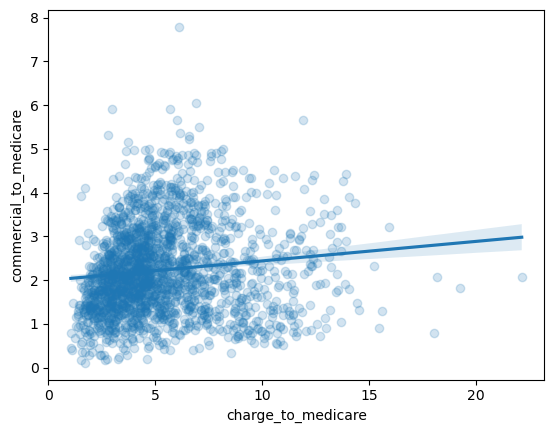

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=hosp,
    x="charge_to_medicare",
    y="commercial_to_medicare",
    scatter_kws={"alpha":0.2}
)

plt.show()

### Correlation Matrix for Core Hospital-Level Price Ratios

This step computes simple pairwise correlations among the three main hospital-level price ratios:
- `commercial_to_medicare`
- `ma_to_medicare`
- `charge_to_medicare`

The results show:
- `commercial_to_medicare` and `charge_to_medicare`: **0.118**
- `commercial_to_medicare` and `ma_to_medicare`: **0.084**
- `ma_to_medicare` and `charge_to_medicare`: **0.031**

All of these correlations are weak. This means the three pricing systems are related only loosely and likely capture different institutional processes. In particular, charge-based pricing does not closely track either commercial negotiated prices or Medicare Advantage pricing. 

In [17]:
print(hosp[[
    "commercial_to_medicare",
    "ma_to_medicare",
    "charge_to_medicare"
]].corr())

                        commercial_to_medicare  ma_to_medicare  \
commercial_to_medicare                 1.00000        0.083860   
ma_to_medicare                         0.08386        1.000000   
charge_to_medicare                     0.11805        0.030984   

                        charge_to_medicare  
commercial_to_medicare            0.118050  
ma_to_medicare                    0.030984  
charge_to_medicare                1.000000  


### Distribution of Hospital Commercial-to-Medicare Ratios

This histogram shows the distribution of hospital-level `commercial_to_medicare` ratios after filtering out implausible extremes.

Most hospitals fall between roughly 1 and 4 times Medicare, with the highest concentration around 1.5 to 3.0. The distribution is right-skewed, meaning there are some hospitals with notably higher negotiated commercial payments, but the majority remain within a relatively interpretable range. This supports using the ratio as a central analytic variable while also motivating later checks for skew and nonlinear effects.

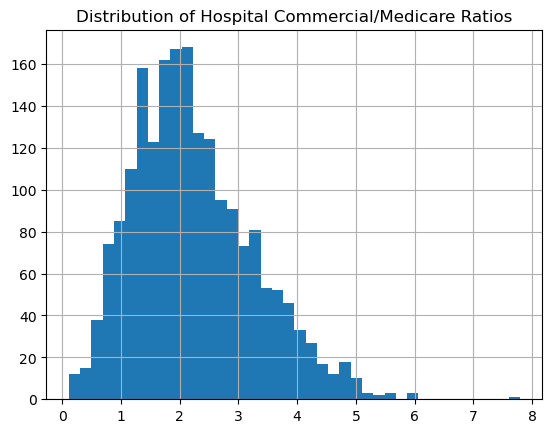

In [18]:
hosp["commercial_to_medicare"].hist(bins=40)
plt.title("Distribution of Hospital Commercial/Medicare Ratios")
plt.show()

### Baseline OLS: Does Charge Inflation Predict Commercial Pricing?

This model regresses `commercial_to_medicare` on `charge_to_medicare` at the hospital level. The purpose is to test whether hospitals with higher charges relative to Medicare also tend to have higher negotiated commercial payment ratios.

The estimated coefficient on `charge_to_medicare` is **0.0446** with **p < 0.001**, indicating a positive statistically significant relationship. However, the model has **R² = 0.014**, meaning charges explain only about 1.4% of the variation in commercial pricing.

This is an important result: charges do have some predictive value for commercial pricing, but only weakly. They are related, but charges alone are far from a strong explanation of negotiated commercial prices.

In [19]:
import statsmodels.api as sm

X = hosp[["charge_to_medicare"]]
X = sm.add_constant(X)

y = hosp["commercial_to_medicare"]

model = sm.OLS(y, X).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     commercial_to_medicare   R-squared:                       0.014
Model:                                OLS   Adj. R-squared:                  0.013
Method:                     Least Squares   F-statistic:                     28.00
Date:                    Fri, 10 Apr 2026   Prob (F-statistic):           1.35e-07
Time:                            11:44:39   Log-Likelihood:                -2846.2
No. Observations:                    1983   AIC:                             5696.
Df Residuals:                        1981   BIC:                             5708.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

### Attach State Information to the Hospital-Level Dataset

The hospital-level pricing dataset does not initially contain a standardized state variable, so this step reconstructs it by pulling the state abbreviation from the merged DRG-level file and linking it back to each hospital using CCN.

The code checks several possible state columns, selects the Medicare state abbreviation field, creates a unique CCN-to-state mapping, and merges that into the hospital-level dataset.

The output confirms that:
- the state column used was `Rndrng_Prvdr_State_Abrvtn`
- the merge was successful
- the missing state rate is **0.0**

This step is necessary because later models use **state fixed effects**, which require a reliable state identifier for every hospital.

In [20]:
import pandas as pd

data_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"
merged_file = data_path + r"\thesis_merged_with_turquoise.csv"

merged = pd.read_csv(merged_file, dtype={"CCN": str}, low_memory=False)

# make sure CCN is 6-digit string
merged["CCN"] = merged["CCN"].str.zfill(6)

# pick a state column that exists (use Medicare state if present; fallback to Turquoise state)
state_col = None
for c in ["Rndrng_Prvdr_State_Abrvtn", "PROVIDER_STATE", "State", "STATE"]:
    if c in merged.columns:
        state_col = c
        break

print("state_col_used:", state_col)

# CCN -> state (take first non-null per CCN)
ccn_state = (
    merged[["CCN", state_col]]
    .dropna()
    .drop_duplicates(subset=["CCN"])
    .rename(columns={state_col: "STATE"})
)

# make sure hosp CCN is formatted same way
hosp["CCN"] = hosp["CCN"].astype(str).str.zfill(6)

# attach state
hosp = hosp.merge(ccn_state, on="CCN", how="left")

print(hosp.columns)
print(hosp["STATE"].isna().mean())

state_col_used: Rndrng_Prvdr_State_Abrvtn
Index(['CCN', 'commercial_to_medicare', 'ma_to_medicare', 'charge_to_medicare',
       'STATE'],
      dtype='object')
0.0


### OLS with State Fixed Effects: Charges and Commercial Pricing Within States

This model estimates the relationship between `charge_to_medicare` and `commercial_to_medicare` while controlling for state fixed effects. State dummy variables are added so the coefficient is identified from variation across hospitals within the same state rather than from differences across states.

The robust HC1 results show:
- `charge_to_medicare` coefficient = **0.0312**
- **p = 0.001**
- **R² = 0.179**
- **n = 1,983 hospitals**

Compared with the baseline model, the charge coefficient remains positive and significant, but model fit increases sharply from **0.014 to 0.179**. This means geography explains a substantial share of commercial pricing variation, but charges still retain a small positive within-state association with negotiated commercial prices. :contentReference[oaicite:1]{index=1}

In [21]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# make sure the key columns are numeric
hosp["commercial_to_medicare"] = pd.to_numeric(hosp["commercial_to_medicare"], errors="coerce")
hosp["charge_to_medicare"] = pd.to_numeric(hosp["charge_to_medicare"], errors="coerce")
hosp["STATE"] = hosp["STATE"].astype(str)

# build X with state fixed effects
state_dummies = pd.get_dummies(hosp["STATE"], drop_first=True, dtype=float)

X = pd.concat([hosp[["charge_to_medicare"]], state_dummies], axis=1)
X = sm.add_constant(X)

y = hosp["commercial_to_medicare"]

# drop rows with any missing after coercion
df = pd.concat([y, X], axis=1).dropna()
y2 = df["commercial_to_medicare"]
X2 = df.drop(columns=["commercial_to_medicare"]).astype(float)

m = sm.OLS(y2, X2).fit()
m_robust = m.get_robustcov_results(cov_type="HC1")

print(m_robust.summary())
print("n used:", int(m_robust.nobs))

                              OLS Regression Results                              
Dep. Variable:     commercial_to_medicare   R-squared:                       0.179
Model:                                OLS   Adj. R-squared:                  0.158
Method:                     Least Squares   F-statistic:                     69.46
Date:                    Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                            11:44:42   Log-Likelihood:                -2664.8
No. Observations:                    1983   AIC:                             5432.
Df Residuals:                        1932   BIC:                             5717.
Df Model:                              50                                         
Covariance Type:                      HC1                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

### Log-Log Model with State Fixed Effects

This step estimates a log-log version of the commercial pricing model:
- dependent variable: `log_comm`
- predictor: `log_charge`
- controls: state fixed effects

The purpose is to test whether the relationship between charges and commercial pricing is more stable in proportional terms and less sensitive to skew.

The results show:
- `log_charge` coefficient = **0.2066**
- **p < 0.001**
- **R² = 0.198**

This implies a positive elasticity-like relationship: hospitals with proportionally higher charge ratios also tend to have proportionally higher commercial ratios. The slightly higher R² relative to the level model suggests the log specification captures the relationship more cleanly. However, the effect is still moderate, not dominant, reinforcing the conclusion that charges are only one limited component of negotiated commercial pricing. :contentReference[oaicite:2]{index=2}

In [22]:
hosp["log_comm"] = np.log(hosp["commercial_to_medicare"])
hosp["log_charge"] = np.log(hosp["charge_to_medicare"])

state_dummies = pd.get_dummies(hosp["STATE"], drop_first=True, dtype=float)

X = pd.concat([hosp[["log_charge"]], state_dummies], axis=1)
X = sm.add_constant(X)

y = hosp["log_comm"]

df = pd.concat([y, X], axis=1).dropna()

m = sm.OLS(df["log_comm"], df.drop(columns=["log_comm"])).fit(cov_type="HC1")

print(m.summary())

                            OLS Regression Results                            
Dep. Variable:               log_comm   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     103.9
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:44:42   Log-Likelihood:                -1286.0
No. Observations:                1983   AIC:                             2674.
Df Residuals:                    1932   BIC:                             2959.
Df Model:                          50                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2210      0.356      0.621      0.5

### Recheck Pairwise Correlations

This cell repeats the correlation matrix for the three main hospital-level price ratios. The purpose is simply to confirm the weak raw relationships before moving to multivariable regression.

The correlations remain very small, reinforcing that simple pairwise association among these price systems is limited and that stronger structure only becomes clearer once controls such as geography are added.

In [23]:
hosp[["commercial_to_medicare",
      "ma_to_medicare",
      "charge_to_medicare"]].corr()

,commercial_to_medicare,ma_to_medicare,charge_to_medicare
commercial_to_medicare,1.00000,0.083860,0.118050
ma_to_medicare,0.08386,1.000000,0.030984
charge_to_medicare,0.11805,0.030984,1.000000


### Prepare a Clean Sample for Multivariable Commercial-Pricing Regression

Before fitting a model with both `ma_to_medicare` and `charge_to_medicare`, this step checks for missing and infinite values.

The output shows:
- `commercial_to_medicare`: 0 missing
- `charge_to_medicare`: 0 missing
- `ma_to_medicare`: **231 missing**
- no infinite values in any variable

After dropping unusable rows, the regression sample contains **1,752 hospitals**. This step is important because Medicare Advantage pricing is less complete than the other ratios, so the multivariable model must be fit on the reduced but valid sample.

### OLS: Commercial Pricing as a Function of MA and Charge Ratios

This model regresses `commercial_to_medicare` on both `ma_to_medicare` and `charge_to_medicare` using robust HC1 standard errors.

The results show:
- `charge_to_medicare` coefficient = **0.0453**, **p < 0.001**
- `ma_to_medicare` coefficient = **0.0760**, **p = 0.441**
- **R² = 0.022**

This means that, conditional on both variables, charge inflation remains a small but statistically significant predictor of commercial pricing, while Medicare Advantage pricing does not. Model fit remains low, so most variation in commercial pricing is still unexplained by these two ratios alone.

Substantively, this suggests that charges and commercial negotiated prices are modestly related, but Medicare Advantage pricing appears much less informative in explaining commercial payment levels in this sample. :contentReference[oaicite:3]{index=3}

In [24]:
import numpy as np
import statsmodels.api as sm

# check what's broken
cols = ["commercial_to_medicare", "ma_to_medicare", "charge_to_medicare"]
print(hosp[cols].isna().sum())

print("inf counts")
for c in cols:
    print(c, np.isinf(hosp[c]).sum())

# keep only usable rows
df = hosp[cols].replace([np.inf, -np.inf], np.nan).dropna()

print("n used:", len(df))

X = sm.add_constant(df[["ma_to_medicare", "charge_to_medicare"]])
y = df["commercial_to_medicare"]

m = sm.OLS(y, X).fit(cov_type="HC1")
print(m.summary())

commercial_to_medicare      0
ma_to_medicare            231
charge_to_medicare          0
dtype: int64
inf counts
commercial_to_medicare 0
ma_to_medicare 0
charge_to_medicare 0
n used: 1752
                              OLS Regression Results                              
Dep. Variable:     commercial_to_medicare   R-squared:                       0.022
Model:                                OLS   Adj. R-squared:                  0.021
Method:                     Least Squares   F-statistic:                     13.01
Date:                    Fri, 10 Apr 2026   Prob (F-statistic):           2.47e-06
Time:                            11:44:42   Log-Likelihood:                -2505.8
No. Observations:                    1752   AIC:                             5018.
Df Residuals:                        1749   BIC:                             5034.
Df Model:                               2                                         
Covariance Type:                      HC1                      

### Build the Hospital-Level Analysis File

This step converts the merged hospital-DRG dataset into a hospital-level analytic file. The main goal is to make the pricing variables comparable to the hospital star rating, which exists at the hospital level rather than the DRG level.

The code first standardizes identifiers (`CCN`, `DRG_Cd`, `Year`), converts the hospital overall rating into a numeric variable (`rating_num`), and creates a `rating_available` indicator. It then forces key payment columns to numeric and constructs the main ratio variables:
- `charge_to_medicare`
- `commercial_to_medicare`
- `ma_to_medicare`

Two additional gap measures are also created to capture the wedge between listed charges and negotiated commercial payments:
- `gap_charge_comm_level`
- `gap_charge_comm_ratio`

Invalid infinite ratio values are set to missing, and observations with nonpositive Medicare payment or nonpositive discharges are removed. The dataset is then aggregated to the hospital level using **discharge-weighted averages**, so higher-volume DRGs contribute more to each hospital’s final pricing measures.

The output shows:
- **3,369 hospitals**
- `charge_to_medicare` available for all hospitals
- `commercial_to_medicare` available for **1,994 hospitals**
- `ma_to_medicare` available for **1,802 hospitals**
- rating available for about **74.9%** of hospitals
- Turquoise coverage for about **59.2%** of hospitals

The summary statistics also show very heavy upper tails for commercial and MA ratios, with maxima above **100**, which motivates later outlier cleaning before regression.

In [25]:
DATA_PATH = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"

WORKING = os.path.join(DATA_PATH, "thesis_working_dataset.csv")
MERGED = os.path.join(DATA_PATH, "thesis_merged_with_turquoise.csv")

df = pd.read_csv(MERGED, low_memory=False)

# Keys
df["CCN"] = df["CCN"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(6)
df["DRG_Cd"] = pd.to_numeric(df["DRG_Cd"], errors="coerce").astype("Int64")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")

# Quality variables
df["rating_num"] = pd.to_numeric(df["Hospital overall rating"].replace("Not Available", np.nan), errors="coerce")
df["rating_available"] = df["rating_num"].notna().astype(int)

# Ensure numeric payment fields
num_cols = [
    "Tot_Dschrgs",
    "Avg_Submtd_Cvrd_Chrg",
    "Avg_Mdcr_Pymt_Amt",
    "AVG_COMMERCIAL",
    "AVG_MEDICARE_ADVANTAGE",
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Ratios (CMS Medicare payment as denominator)
den = df["Avg_Mdcr_Pymt_Amt"]
df["charge_to_medicare"] = df["Avg_Submtd_Cvrd_Chrg"] / den
df["commercial_to_medicare"] = df["AVG_COMMERCIAL"] / den
df["ma_to_medicare"] = df["AVG_MEDICARE_ADVANTAGE"] / den

# Gap between charges and commercial payment (level and ratio form)
df["gap_charge_comm_level"] = df["Avg_Submtd_Cvrd_Chrg"] - df["AVG_COMMERCIAL"]
df["gap_charge_comm_ratio"] = df["Avg_Submtd_Cvrd_Chrg"] / df["AVG_COMMERCIAL"]

# Basic validity filters
ratio_cols = ["charge_to_medicare", "commercial_to_medicare", "ma_to_medicare", "gap_charge_comm_ratio"]
for c in ratio_cols:
    df.loc[~np.isfinite(df[c]), c] = np.nan

df = df[df["Avg_Mdcr_Pymt_Amt"] > 0].copy()
df = df[df["Tot_Dschrgs"] > 0].copy()

# Hospital-level aggregation (weighted by Medicare discharges)
w = df["Tot_Dschrgs"]

def wavg(x, w):
    m = x.notna() & w.notna()
    if m.sum() == 0:
        return np.nan
    return np.average(x[m], weights=w[m])

group_cols = ["CCN"]
keep_first = [
    "Rndrng_Prvdr_Org_Name",
    "Rndrng_Prvdr_State_Abrvtn",
    "Rndrng_Prvdr_RUCA_Desc",
    "Hospital Type",
    "Hospital Ownership",
    "Emergency Services",
    "has_hosp_info",
]

agg = df.groupby(group_cols, dropna=False).apply(
    lambda g: pd.Series({
        "STATE": g["Rndrng_Prvdr_State_Abrvtn"].dropna().iloc[0] if g["Rndrng_Prvdr_State_Abrvtn"].notna().any() else np.nan,
        "Tot_Dschrgs_sum": g["Tot_Dschrgs"].sum(),
        "rating_num": g["rating_num"].dropna().iloc[0] if g["rating_num"].notna().any() else np.nan,
        "rating_available": int(g["rating_num"].notna().any()),
        "charge_to_medicare": wavg(g["charge_to_medicare"], g["Tot_Dschrgs"]),
        "commercial_to_medicare": wavg(g["commercial_to_medicare"], g["Tot_Dschrgs"]),
        "ma_to_medicare": wavg(g["ma_to_medicare"], g["Tot_Dschrgs"]),
        "gap_charge_comm_level": wavg(g["gap_charge_comm_level"], g["Tot_Dschrgs"]),
        "gap_charge_comm_ratio": wavg(g["gap_charge_comm_ratio"], g["Tot_Dschrgs"]),
        "has_turquoise": int(g["has_turquoise"].fillna(0).max()),
    })
).reset_index()

# Attach stable hospital descriptors (first non-missing per CCN)
meta = (
    df[["CCN"] + [c for c in keep_first if c in df.columns]]
    .sort_values(["CCN"])
    .groupby("CCN", as_index=False)
    .first()
)

hosp = agg.merge(meta, on="CCN", how="left")

OUT = os.path.join(DATA_PATH, "analysis_hospital_level_ready.csv")
hosp.to_csv(OUT, index=False)

print("Saved:", OUT)
print("Hospitals:", hosp.shape[0])
print(hosp[["charge_to_medicare", "commercial_to_medicare", "ma_to_medicare"]].describe().T)
print("Rating available:", hosp["rating_available"].mean())
print("Has turquoise:", hosp["has_turquoise"].mean())

C:\Users\priva\AppData\Local\Temp\ipykernel_57764\3454552025.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = df.groupby(group_cols, dropna=False).apply(


Saved: C:\Users\priva\OneDrive\Documents\Honors Project\Data\analysis_hospital_level_ready.csv
Hospitals: 3369
                         count      mean        std       min       25%  \
charge_to_medicare      3369.0  4.851163   2.563739  0.283715  3.077503   
commercial_to_medicare  1994.0  2.628272   5.915489  0.031218  1.462016   
ma_to_medicare          1802.0  2.152842  10.249887  0.000152  1.211005   

                             50%       75%         max  
charge_to_medicare      4.328126  5.997648   21.471191  
commercial_to_medicare  2.092536  2.870820  131.270763  
ma_to_medicare          1.363224  1.510970  167.259334  
Rating available: 0.7491837340457109
Has turquoise: 0.5918670228554467


### Clean Extreme Ratio Outliers for Modeling

This step removes extreme outliers from the main ratio variables using the **1.5 × IQR rule**. Instead of deleting entire hospitals immediately, outlying ratio values are set to missing for:
- `charge_to_medicare`
- `commercial_to_medicare`
- `ma_to_medicare`
- `gap_charge_comm_ratio`

After this, the modeling sample is restricted to hospitals with both a valid `commercial_to_medicare` ratio and a nonmissing `rating_num`.

The output shows:
- cleaned sample size = **1,702 hospitals**
- `commercial_to_medicare` mean ≈ **2.22**, max ≈ **4.94**
- `ma_to_medicare` mean ≈ **1.35**, max ≈ **1.95**
- `charge_to_medicare` mean ≈ **4.91**, max ≈ **10.36**

Compared with the uncleaned file, the extreme tails are greatly reduced. This produces a much more stable regression sample and prevents a small number of extreme hospitals from dominating the results.

In [26]:
FILE = os.path.join(DATA_PATH, "analysis_hospital_level_ready.csv")

df = pd.read_csv(FILE)

# IQR outlier removal for ratio variables
ratio_cols = [
    "charge_to_medicare",
    "commercial_to_medicare",
    "ma_to_medicare",
    "gap_charge_comm_ratio"
]

for c in ratio_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df.loc[(df[c] < lower) | (df[c] > upper), c] = np.nan

# Keep hospitals with valid commercial ratio and rating
df_model = df[
    df["commercial_to_medicare"].notna() &
    df["rating_num"].notna()
].copy()

# Save cleaned dataset
OUT = os.path.join(DATA_PATH, "analysis_hospital_level_clean.csv")
df_model.to_csv(OUT, index=False)

print("Saved:", OUT)
print("N hospitals:", df_model.shape[0])
print(df_model[["charge_to_medicare","commercial_to_medicare","ma_to_medicare"]].describe().T)

Saved: C:\Users\priva\OneDrive\Documents\Honors Project\Data\analysis_hospital_level_clean.csv
N hospitals: 1702
                         count      mean       std       min       25%  \
charge_to_medicare      1583.0  4.909229  1.978207  0.899260  3.414476   
commercial_to_medicare  1702.0  2.217003  0.972685  0.031218  1.471674   
ma_to_medicare          1384.0  1.354311  0.212721  0.761296  1.230530   

                             50%       75%        max  
charge_to_medicare      4.509180  6.113835  10.357423  
commercial_to_medicare  2.125635  2.855960   4.942229  
ma_to_medicare          1.362349  1.492574   1.954689  


### Baseline OLS: Quality on Commercial Pricing

This is the simplest quality model in the analysis. It regresses the numeric hospital star rating (`rating_num`) on `commercial_to_medicare` using heteroskedasticity-robust HC1 standard errors.

The results show:
- `commercial_to_medicare` coefficient = **0.2305**
- **p < 0.001**
- **R² = 0.043**

This means hospitals with higher commercial payments relative to Medicare tend to have higher quality ratings on average. The effect is statistically strong, but explanatory power is modest, which is expected because hospital ratings reflect many factors beyond payment ratios. This model establishes the core empirical relationship that the rest of the analysis tests for robustness.

In [27]:
# rating as numeric
df["rating_num"] = pd.to_numeric(df["rating_num"], errors="coerce")

# baseline: rating ~ commercial_to_medicare
y = df["rating_num"]
X = sm.add_constant(df[["commercial_to_medicare"]])
m1 = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
m1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     78.73
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.77e-18
Time:                        11:44:56   Log-Likelihood:                -2519.0
No. Observations:                1702   AIC:                             5042.
Df Residuals:                    1700   BIC:                             5053.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2.5336      0.063     39.982      0.000       2.409       2.658
commercial_to_medicare     0.2305      0.026      8.873      0.000       0.180       0.281
==============================================================================
Omnibus:                       61.791   Durbin-Watson:                   1.826
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.381
Skew:                          -0.046   Prob(JB):                     6.87e-07
Kurtosis:                       2.374   Cond. No.                         6.91
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

### Add Charge Inflation to the Baseline Quality Model

This step extends the baseline OLS model by adding `charge_to_medicare` alongside `commercial_to_medicare`.

The purpose is to test whether submitted charges carry information about hospital quality once commercial pricing is already in the model. This helps distinguish whether negotiated commercial prices and listed hospital charges are capturing the same phenomenon or different ones.

The key interpretation from this model is that commercial pricing remains the main variable of interest, while charge-based pricing is expected to add little if charges mostly reflect billing strategy rather than underlying quality.

In [28]:
# add charge inflation
X2 = sm.add_constant(df[["commercial_to_medicare", "charge_to_medicare"]])
m2 = sm.OLS(y, X2, missing="drop").fit(cov_type="HC1")
m2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     37.93
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           8.13e-17
Time:                        11:44:56   Log-Likelihood:                -2331.8
No. Observations:                1583   AIC:                             4670.
Df Residuals:                    1580   BIC:                             4686.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2.5765      0.090     28.521      0.000       2.399       2.754
commercial_to_medicare     0.2379      0.027      8.691      0.000       0.184       0.292
charge_to_medicare        -0.0035      0.014     -0.261      0.794      -0.030       0.023
==============================================================================
Omnibus:                       53.081   Durbin-Watson:                   1.869
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               25.449
Skew:                          -0.063   Prob(JB):                     2.98e-06
Kurtosis:                       2.392   Cond. No.                         19.9
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

### Add Hospital Ownership, Type, and Emergency Controls

This model adds hospital-level structural controls to the quality regression. Dummy variables are created for:
- `Hospital Ownership`
- `Hospital Type`
- `Emergency Services`

These controls are added to test whether the pricing-quality relationship survives after accounting for broad institutional differences across hospitals.

The output shows:
- **R² = 0.074**
- `commercial_to_medicare` coefficient = **0.1955**, **p < 0.001**
- `charge_to_medicare` coefficient = **0.0116**, **p = 0.445**

So compared with the baseline model:
- commercial pricing remains positive and highly significant
- charges remain insignificant
- model fit improves from **0.043 to 0.074**

This means part of the variation in quality is explained by hospital characteristics, but the main commercial-pricing relationship remains intact. The warning about singularity or multicollinearity reflects the dummy-variable structure rather than overturning the core result.

In [29]:
# add ownership, type, emergency
controls = ["commercial_to_medicare", "charge_to_medicare"]

for c in ["Hospital Ownership", "Hospital Type", "Emergency Services"]:
    if c in df.columns:
        d = pd.get_dummies(df[c], drop_first=True, dtype=float)
        df = pd.concat([df, d], axis=1)
        controls += d.columns.tolist()

X3 = sm.add_constant(df[controls])
m3 = sm.OLS(y, X3, missing="drop").fit(cov_type="HC1")
m3.summary()

c:\Users\priva\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 11
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     12.01
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           6.25e-22
Time:                        11:44:56   Log-Likelihood:                -2307.4
No. Observations:                1583   AIC:                             4639.
Df Residuals:                    1571   BIC:                             4703.
Df Model:                          11                                         
Covariance Type:                  HC1                                         
===============================================================================================================
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
const                                           3.3796      0.493      6.850      0.000       2.413       4.347
commercial_to_medicare                          0.1955      0.029      6.815      0.000       0.139       0.252
charge_to_medicare                              0.0116      0.015      0.764      0.445      -0.018       0.041
Government - Hospital District or Authority    -0.7486      0.492     -1.523      0.128      -1.712       0.215
Government - Local                             -0.8993      0.501     -1.795      0.073      -1.881       0.083
Government - State                             -0.6660      0.522     -1.277      0.202      -1.688       0.356
Physician                                      -0.0007      0.587     -0.001      0.999      -1.151       1.150
Proprietary                                    -0.7825      0.487     -1.607      0.108      -1.737       0.172
Tribal                                       1.311e-16    7.3e-17      1.795      0.073   -1.21e-17    2.74e-16
Voluntary non-profit - Church                  -0.3381      0.488     -0.693      0.488      -1.295       0.618
Voluntary non-profit - Other                   -0.6003      0.488     -1.229      0.219      -1.557       0.357
Voluntary non-profit - Private                 -0.4123      0.482     -0.856      0.392      -1.356       0.532
Yes                                            -0.2691      0.123     -2.193      0.028      -0.510      -0.029
==============================================================================
Omnibus:                       46.732   Durbin-Watson:                   1.882
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.004
Skew:                          -0.039   Prob(JB):                     1.01e-05
Kurtosis:                       2.415   Cond. No.                     4.92e+17
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The smallest eigenvalue is 2.27e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

### Add State Fixed Effects to the Quality Model

This model adds **state fixed effects** by creating state dummy variables and including them in the regression. This means the coefficient on `commercial_to_medicare` is identified using only differences across hospitals within the same state, rather than across states.

The results show:
- **R² = 0.165**
- `commercial_to_medicare` coefficient = **0.2298**, **p < 0.001**
- `charge_to_medicare` coefficient = **0.0040**, **p = 0.805**

This is one of the most important robustness checks in the thesis. Adding state fixed effects raises model fit sharply from **0.074 to 0.165**, showing that geography explains a substantial share of rating variation. However, the commercial-pricing coefficient remains large, positive, and highly significant, while charges remain irrelevant.

The interpretation is that the core relationship is not just driven by some states having both higher prices and higher ratings. It also holds when hospitals are compared within the same state.

In [30]:
# state fixed effects
state_d = pd.get_dummies(df["STATE"], drop_first=True, dtype=float)
X4 = pd.concat([df[["commercial_to_medicare", "charge_to_medicare"]], state_d], axis=1)
X4 = sm.add_constant(X4)

m4 = sm.OLS(y, X4, missing="drop").fit(cov_type="HC1")
m4.summary()

c:\Users\priva\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 52, but rank is 51
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     47.94
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          7.79e-277
Time:                        11:44:56   Log-Likelihood:                -2225.6
No. Observations:                1583   AIC:                             4555.
Df Residuals:                    1531   BIC:                             4834.
Df Model:                          51                                         
Covariance Type:                  HC1                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2.2716      0.617      3.681      0.000       1.062       3.481
commercial_to_medicare     0.2298      0.030      7.642      0.000       0.171       0.289
charge_to_medicare         0.0040      0.016      0.247      0.805      -0.028       0.036
AL                        -0.1779      0.629     -0.283      0.777      -1.410       1.054
AR                        -0.2245      0.663     -0.339      0.735      -1.523       1.074
AZ                        -0.0044      0.620     -0.007      0.994      -1.219       1.210
CA                         0.3392      0.615      0.551      0.582      -0.867       1.545
CO                         0.7404      0.639      1.158      0.247      -0.512       1.993
CT                         0.2417      0.631      0.383      0.702      -0.996       1.479
DC                        -0.8550      0.707     -1.209      0.227      -2.240       0.531
DE                         0.7316      0.890      0.822      0.411      -1.012       2.476
FL                         0.1305      0.618      0.211      0.833      -1.081       1.342
GA                        -0.0490      0.641     -0.076      0.939      -1.306       1.208
HI                         0.4918      0.683      0.720      0.472      -0.847       1.831
IA                         0.1639      0.660      0.248      0.804      -1.130       1.458
ID                         0.9913      0.669      1.481      0.139      -0.321       2.303
IL                        -0.0107      0.625     -0.017      0.986      -1.236       1.214
IN                         0.1948      0.621      0.314      0.754      -1.022       1.411
KS                         0.8191      0.651      1.258      0.208      -0.457       2.096
KY                        -0.1285      0.627     -0.205      0.838      -1.358       1.101
LA                         0.2100      0.628      0.334      0.738      -1.021       1.441
MA                         0.0264      0.634      0.042      0.967      -1.215       1.268
MD                     -2.089e-15   9.44e-16     -2.213      0.027   -3.94e-15   -2.39e-16
ME                        -0.5420      0.611     -0.888      0.375      -1.739       0.655
MI                         0.2569      0.626      0.410      0.682      -0.971       1.484
MN                         1.0978      0.627      1.750      0.080      -0.132       2.327
MO                         0.7476      0.623      1.200      0.230      -0.473       1.968
MS                        -0.3966      0.647     -0.613      0.540      -1.664       0.871
MT                         0.2696      0.761      0.354      0.723      -1.221       1.760
NC                         0.1810      0.626      0.289      0.773      -1.046       1.408
ND                         0.7056      0.747      0.944      0.345      -0.759  

### Inspect the Distribution of Commercial-to-Medicare Ratios in the Clean Sample

This step summarizes the cleaned `commercial_to_medicare` variable after outlier treatment.

The output shows:
- count = **1,969**
- mean ≈ **2.20**
- median ≈ **2.08**
- 75th percentile ≈ **2.83**
- max ≈ **4.95**

This confirms that, after cleaning, the commercial pricing ratio is concentrated in a plausible range. Most hospitals receive commercial payments between roughly 1.5 and 3 times Medicare, with a moderate right tail still present. This supports interpreting the regression coefficients on a realistic scale rather than being driven by a few extreme hospitals.

In [31]:
df["commercial_to_medicare"].describe()

count    1969.000000
mean        2.200195
std         0.984391
min         0.031218
25%         1.449497
50%         2.083317
75%         2.833683
max         4.945444
Name: commercial_to_medicare, dtype: float64

### Define a Binary High-Quality Outcome and Estimate a Logit Model

This step creates a binary indicator `high_quality`, equal to 1 when a hospital has a star rating of 4 or 5, and 0 otherwise. A logistic regression is then estimated using:
- `commercial_to_medicare`
- `charge_to_medicare`

The results show:
- `commercial_to_medicare` coefficient = **0.3631**, **p < 0.001**
- `charge_to_medicare` coefficient = **0.0279**, **p = 0.285**
- Pseudo R² = **0.023**

This confirms the same basic pattern seen in OLS: higher commercial payment ratios are associated with better hospital quality, while charge inflation is not. The lower pseudo R² is normal for logistic models and does not contradict the significance of the commercial effect.

In [32]:
df["high_quality"] = (df["rating_num"] >= 4).astype(int)

y = df["high_quality"]
X = sm.add_constant(df[["commercial_to_medicare", "charge_to_medicare"]])

logit = sm.Logit(y, X, missing="drop").fit(disp=False)
logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           high_quality   No. Observations:                 1843
Model:                          Logit   Df Residuals:                     1840
Method:                           MLE   Df Model:                            2
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                 0.02345
Time:                        11:44:56   Log-Likelihood:                -1125.4
converged:                       True   LL-Null:                       -1152.5
Covariance Type:            nonrobust   LLR p-value:                 1.835e-12
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -1.7219      0.170    -10.124      0.000      -2.055      -1.389
commercial_to_medicare     0.3631      0.052      6.954      0.000       0.261       0.465
charge_to_medicare         0.0279      0.026      1.068      0.285      -0.023       0.079
==========================================================================================
"""

### Interpret the Logit Model Using Marginal Effects

After fitting the logistic model, this step computes average marginal effects to translate log-odds coefficients into probability terms.

The output shows:
- `commercial_to_medicare` marginal effect = **0.0764**, **p < 0.001**
- `charge_to_medicare` marginal effect = **0.0059**, **p = 0.285**

This means that, on average, a one-unit increase in the commercial-to-Medicare ratio is associated with about a **7.6 percentage point increase** in the probability of being a 4–5 star hospital. Charge inflation again has no statistically meaningful effect.

This makes the main finding easier to interpret substantively: higher negotiated commercial payments are associated not only with higher average ratings, but also with a higher probability of belonging to the high-quality group.

In [33]:
marg = logit.get_margeff()
marg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:           high_quality
Method:                          dydx
At:                           overall
==========================================================================================
                            dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
commercial_to_medicare     0.0764      0.010      7.297      0.000       0.056       0.097
charge_to_medicare         0.0059      0.005      1.069      0.285      -0.005       0.017
==========================================================================================
"""

### Check Outcome Variation by State Before State-Level Logit Extensions

Before estimating logistic models with state fixed effects, this step checks whether each state has variation in the binary `high_quality` outcome.

For fixed-effects logit models to be identified, each state needs at least one high-quality hospital and at least one non-high-quality hospital. The table computes:
- count of hospitals
- count of high-quality hospitals
- mean high-quality rate
- `var_ok`, indicating whether within-state variation exists

The output shows:
- **48 states** have valid outcome variation
- **2 states** do not

This is an important diagnostic because states with no variation in the outcome cannot contribute to a fixed-effects logit model. The step ensures that later within-state binary models are estimated on a valid sample.

In [34]:
tmp = df[["STATE", "high_quality", "commercial_to_medicare", "charge_to_medicare"]].dropna()

g = tmp.groupby("STATE")["high_quality"].agg(["count", "sum"])
g["mean"] = g["sum"] / g["count"]
g["var_ok"] = (g["sum"] > 0) & (g["sum"] < g["count"])

g.sort_values(["var_ok", "count", "mean"]).head(20), g["var_ok"].value_counts()

(       count  sum      mean  var_ok
 STATE                              
 ME         1    0  0.000000   False
 DC         5    0  0.000000   False
 DE         3    1  0.333333    True
 MT         3    1  0.333333    True
 VT         4    1  0.250000    True
 RI         4    2  0.500000    True
 ND         4    3  0.750000    True
 AK         5    1  0.200000    True
 WY         6    1  0.166667    True
 NH         9    4  0.444444    True
 HI        10    4  0.400000    True
 SD        10    7  0.700000    True
 NV        12    2  0.166667    True
 ID        12    6  0.500000    True
 NM        13    1  0.076923    True
 WV        16    1  0.062500    True
 CT        17    4  0.235294    True
 NE        17    5  0.294118    True
 OR        19    7  0.368421    True
 AR        20    3  0.150000    True,
 var_ok
 True     48
 False     2
 Name: count, dtype: int64)

### Logistic Regression with State Fixed Effects

This step estimates a logistic regression for the binary outcome `high_quality` while adding **state fixed effects**. Before fitting the model, states with no variation in the outcome are excluded, since fixed-effects logit requires each included state to contain at least one high-quality and one non-high-quality hospital.

The model includes:
- `commercial_to_medicare`
- `charge_to_medicare`
- state dummy variables

The results show:
- `commercial_to_medicare` coefficient = **0.3668**, **p < 0.001**
- `charge_to_medicare` coefficient = **0.0712**, **p = 0.028**
- Pseudo R² = **0.087**

Compared with the simpler logit model, the commercial effect remains strong and highly significant even after restricting the comparison to hospitals within the same state. The charge ratio, which was not significant in the pooled logit model, becomes positive and statistically significant here. This suggests that some charge variation may contain information about quality once broad geographic differences are held constant.

In [35]:
keep_states = g.index[g["var_ok"]].tolist()

d = tmp[tmp["STATE"].isin(keep_states)].copy()
state_d = pd.get_dummies(d["STATE"], drop_first=True, dtype=float)

X_fe = pd.concat([d[["commercial_to_medicare", "charge_to_medicare"]], state_d], axis=1)
X_fe = sm.add_constant(X_fe)

logit_fe = sm.Logit(d["high_quality"], X_fe).fit(disp=False)
logit_fe.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           high_quality   No. Observations:                 1837
Model:                          Logit   Df Residuals:                     1787
Method:                           MLE   Df Model:                           49
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                 0.08724
Time:                        11:44:56   Log-Likelihood:                -1049.8
converged:                       True   LL-Null:                       -1150.2
Covariance Type:            nonrobust   LLR p-value:                 2.969e-20
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2.5041      1.134     -2.208      0.027      -4.727      -0.281
commercial_to_medicare     0.3668      0.060      6.104      0.000       0.249       0.485
charge_to_medicare         0.0712      0.032      2.198      0.028       0.008       0.135
AL                        -1.4323      1.336     -1.072      0.284      -4.050       1.186
AR                        -0.1978      1.285     -0.154      0.878      -2.716       2.321
AZ                        -0.5046      1.188     -0.425      0.671      -2.833       1.824
CA                         0.7074      1.135      0.623      0.533      -1.517       2.932
CO                         1.0163      1.173      0.867      0.386      -1.282       3.315
CT                         0.2017      1.259      0.160      0.873      -2.265       2.668
DE                         0.4978      1.670      0.298      0.766      -2.775       3.770
FL                         0.5796      1.141      0.508      0.612      -1.657       2.816
GA                         0.2117      1.166      0.182      0.856      -2.074       2.497
HI                         1.1793      1.294      0.911      0.362      -1.357       3.715
IA                         0.4406      1.204      0.366      0.714      -1.919       2.800
ID                         1.1775      1.262      0.933      0.351      -1.296       3.651
IL                         0.3879      1.156      0.336      0.737      -1.877       2.653
IN                         0.0873      1.163      0.075      0.940      -2.192       2.367
KS                         1.1623      1.185      0.981      0.327      -1.161       3.485
KY                        -0.1605      1.186     -0.135      0.892      -2.485       2.164
LA                         0.0056      1.195      0.005      0.996      -2.337       2.348
MA                         0.2162      1.249      0.173      0.863      -2.232       2.664
MI                         0.9664      1.158      0.834      0.404      -1.304       3.237
MN                         1.9968      1.166      1.712      0.087      -0.289       4.283
MO                         1.6713      1.176      1.422      0.155      -0.633       3.975
MS                        -0.9568      1.343     -0.713      0.476      -3.588       1.675
MT                         0.8369      1.665      0.503      0.615      -2.426       4.099
NC                         0.3008      1.161      0.259      0.796      -1.975       2.576
ND                         2.5678      1.609      1.596      0.111      -0.586       5.721
NE                         0.2894      1.241      0.233      0.816      -2.144       2.723
NH                         1.2785      1.308      0.977      0.328      -1.285       3.842
NJ                        -0.0717      1.176     -0.061      0.951      -2.376       2.233
NM                        -0.9314      1.531     -0.608      0.543      -3.933       2.070
NV                        -0.6642      1.374     -0.483 

### Marginal Effects from the State Fixed-Effects Logit Model

This step converts the fixed-effects logit coefficients into average marginal effects, which are easier to interpret than log-odds.

The results show:
- `commercial_to_medicare` marginal effect = **0.0714**, **p < 0.001**
- `charge_to_medicare` marginal effect = **0.0139**, **p = 0.027**

This means that, holding the state fixed, a one-unit increase in the commercial-to-Medicare ratio is associated with about a **7.1 percentage point increase** in the probability of being a 4–5 star hospital. A one-unit increase in the charge-to-Medicare ratio is associated with about a **1.4 percentage point increase** in that probability.

The commercial effect remains the dominant result, but the charge effect becomes detectable in the within-state binary model.

In [36]:
logit_fe.get_margeff().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:           high_quality
Method:                          dydx
At:                           overall
==========================================================================================
                            dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
commercial_to_medicare     0.0714      0.011      6.331      0.000       0.049       0.093
charge_to_medicare         0.0139      0.006      2.207      0.027       0.002       0.026
AL                        -0.2787      0.260     -1.073      0.283      -0.788       0.231
AR                        -0.0385      0.250     -0.154      0.878      -0.528       0.451
AZ                        -0.0982      0.231     -0.425      0.671      -0.551       0.355
CA                         0.1376      0.221      0.623      0.533      -0.295       0.570
CO                         0.1977      0.228      0.867      0.386      -0.249       0.645
CT                         0.0392      0.245      0.160      0.873      -0.441       0.519
DE                         0.0968      0.325      0.298      0.766      -0.540       0.733
FL                         0.1128      0.222      0.508      0.611      -0.322       0.548
GA                         0.0412      0.227      0.182      0.856      -0.403       0.486
HI                         0.2294      0.252      0.912      0.362      -0.264       0.722
IA                         0.0857      0.234      0.366      0.714      -0.373       0.545
ID                         0.2291      0.245      0.934      0.350      -0.252       0.710
IL                         0.0755      0.225      0.336      0.737      -0.365       0.516
IN                         0.0170      0.226      0.075      0.940      -0.426       0.460
KS                         0.2261      0.230      0.982      0.326      -0.225       0.678
KY                        -0.0312      0.231     -0.135      0.892      -0.483       0.421
LA                         0.0011      0.233      0.005      0.996      -0.455       0.457
MA                         0.0421      0.243      0.173      0.863      -0.434       0.518
MI                         0.1880      0.225      0.835      0.404      -0.253       0.629
MN                         0.3885      0.226      1.717      0.086      -0.055       0.832
MO                         0.3251      0.228      1.424      0.154      -0.122       0.773
MS                        -0.1861      0.261     -0.713      0.476      -0.698       0.326
MT                         0.1628      0.324      0.503      0.615      -0.472       0.797
NC                         0.0585      0.226      0.259      0.796      -0.384       0.501
ND                         0.4996      0.312      1.600      0.110      -0.112       1.111
NE                         0.0563      0.242      0.233      0.816      -0.417       0.530
NH                         0.2487      0.254      0.978      0.328      -0.250       0.747
NJ                        -0.0140      0.229     -0.061      0.951      -0.462       0.434
NM                        -0.1812      0.298     -0.608      0.543      -0.765       0.403
NV                        -0.1292      0.267     -0.484      0.629      -0.653       0.395
NY                        -0.0471      0.224     -0.211      0.833      -0.485       0.391
OH                         0.1960      0.225      0.872      0.383      -0.245       0.637
OK                         0.2102      0.230      0.916      0.360      -0.240       0.660
OR                         0.1553      0.237      0.655      0.512      -0.309       0.620
PA                         0.1473      0.221      0.666      0.505      -0.286       0.581
RI                         0.3228      0.292      1.106      0.269      -0.249       0.895
SC                         0.09

### Log Specification for Commercial Pricing in the Quality Model

This model replaces the level form of commercial pricing with its logarithm:
- `log_comm`
- `charge_to_medicare`

The purpose is to test whether the relationship between commercial pricing and quality is more stable in proportional terms and less sensitive to skew.

The results show:
- `log_comm` coefficient = **0.4434**, **p < 0.001**
- `charge_to_medicare` coefficient = **-0.0003**, **p = 0.984**
- **R² = 0.043**

This closely matches the baseline OLS result in explanatory power, while confirming that the commercial effect remains strongly positive under a log transformation. The charge ratio remains completely uninformative. This suggests the pricing-quality relationship is robust to scale transformation and not driven by a small number of extreme high-price hospitals.

In [37]:
df["log_comm"] = np.log(df["commercial_to_medicare"])

y = df["rating_num"]
X = sm.add_constant(df[["log_comm", "charge_to_medicare"]])

m_log = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
m_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     37.96
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           7.90e-17
Time:                        11:44:57   Log-Likelihood:                -2332.9
No. Observations:                1583   AIC:                             4672.
Df Residuals:                    1580   BIC:                             4688.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.7841      0.079     35.398      0.000       2.630       2.938
log_comm               0.4434      0.051      8.705      0.000       0.344       0.543
charge_to_medicare    -0.0003      0.014     -0.021      0.984      -0.027       0.026
==============================================================================
Omnibus:                       55.883   Durbin-Watson:                   1.869
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               26.431
Skew:                          -0.068   Prob(JB):                     1.82e-06
Kurtosis:                       2.382   Cond. No.                         16.7
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

### OLS Model Using Medicare Advantage and Charge Ratios

This model tests whether hospital quality can be explained by:
- `ma_to_medicare`
- `charge_to_medicare`

The purpose is to check whether Medicare Advantage pricing carries similar information to commercial pricing once quality is the outcome.

The results show:
- `ma_to_medicare` coefficient = **0.0699**, **p = 0.625**
- `charge_to_medicare` coefficient = **0.0030**, **p = 0.844**
- **R² = 0.000**

This model has essentially no explanatory power. Neither Medicare Advantage pricing nor charge inflation predicts hospital ratings in this sample. This strengthens the interpretation that the main signal is specific to **commercial negotiated pricing**, not to all non-Medicare payment ratios.

In [38]:
y = df["rating_num"]
X = sm.add_constant(df[["ma_to_medicare", "charge_to_medicare"]])

m_ma = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
m_ma.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.1603
Date:                Fri, 10 Apr 2026   Prob (F-statistic):              0.852
Time:                        11:44:57   Log-Likelihood:                -1966.8
No. Observations:                1319   AIC:                             3940.
Df Residuals:                    1316   BIC:                             3955.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.9726      0.197     15.071      0.000       2.586       3.359
ma_to_medicare         0.0699      0.143      0.488      0.625      -0.211       0.350
charge_to_medicare     0.0030      0.015      0.196      0.844      -0.027       0.033
==============================================================================
Omnibus:                       63.319   Durbin-Watson:                   1.808
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               26.166
Skew:                          -0.039   Prob(JB):                     2.08e-06
Kurtosis:                       2.314   Cond. No.                         44.4
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

### Binned Relationship Between Commercial Pricing and Hospital Quality

This figure groups hospitals into ten bins based on `commercial_to_medicare` and then plots the average hospital star rating within each bin. The purpose is to visualize the relationship between negotiated commercial payment levels and quality without forcing a strictly linear specification.

The plot shows a generally upward pattern: hospitals with higher commercial-to-Medicare payment ratios tend to have higher average star ratings. The increase is not perfectly smooth, but the overall direction is clearly positive. This supports the regression results showing that higher commercial pricing is associated with higher quality and also suggests that the relationship may be somewhat nonlinear or tiered rather than perfectly continuous.

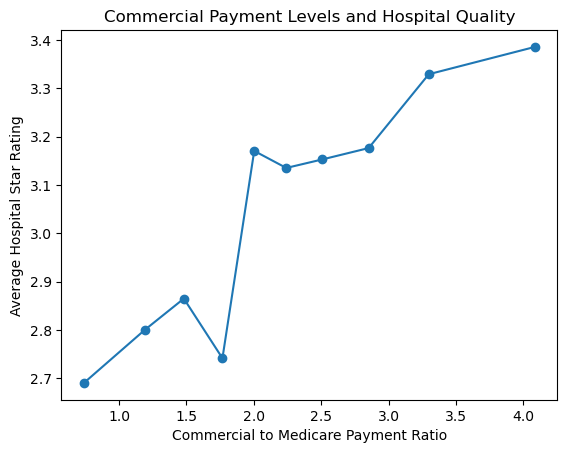

In [39]:
d = df[["commercial_to_medicare","rating_num"]].dropna().copy()
d["bin"] = pd.qcut(d["commercial_to_medicare"],10,duplicates="drop")

b = d.groupby("bin",observed=True).agg(
    mid=("commercial_to_medicare","mean"),
    mean_rating=("rating_num","mean")
).reset_index(drop=True)

plt.figure()
plt.plot(b["mid"],b["mean_rating"],marker="o")
plt.xlabel("Commercial to Medicare Payment Ratio")
plt.ylabel("Average Hospital Star Rating")
plt.title("Commercial Payment Levels and Hospital Quality")
plt.show()

### Distribution of Hospital Charges Relative to Medicare

This histogram shows the distribution of `charge_to_medicare` in the cleaned hospital-level sample. The goal is to understand how submitted hospital charges compare with Medicare reimbursement across hospitals.

The distribution is right-skewed, with most hospitals concentrated around roughly 2 to 6 times Medicare payment and a longer upper tail extending beyond 10. This confirms that hospital charges are usually several times larger than Medicare reimbursement and vary widely across providers. That wide spread is consistent with the idea that charges reflect heterogeneous billing behavior rather than a direct measure of quality.

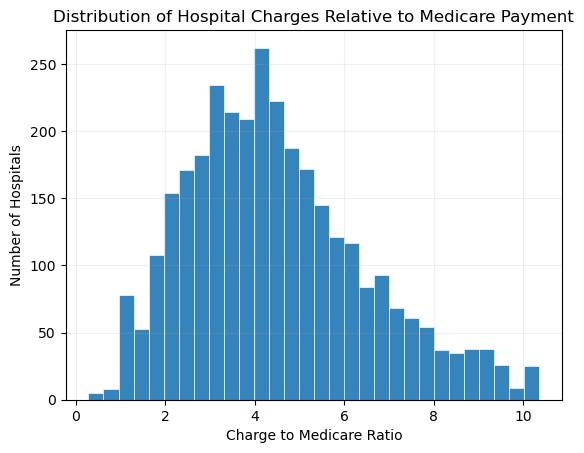

In [40]:
x = df["charge_to_medicare"].dropna()

plt.figure()
plt.hist(x, bins=30, edgecolor="white", linewidth=0.5, alpha=0.9)
plt.grid(True, alpha=0.20)
plt.xlabel("Charge to Medicare Ratio")
plt.ylabel("Number of Hospitals")
plt.title("Distribution of Hospital Charges Relative to Medicare Payment")
plt.show()

### Distribution of Commercial Payments Relative to Medicare

This histogram shows the distribution of `commercial_to_medicare` in the cleaned hospital-level sample. The goal is to visualize the range of negotiated commercial pricing after removing extreme outliers.

Most hospitals fall between roughly 1 and 3 times Medicare, with the highest concentration around 1.5 to 2.5. The right tail remains present but is much less extreme than in the raw data. Compared with the charge ratio distribution, commercial pricing is more concentrated and economically interpretable. This makes it a stronger candidate for modeling how negotiated prices relate to quality.

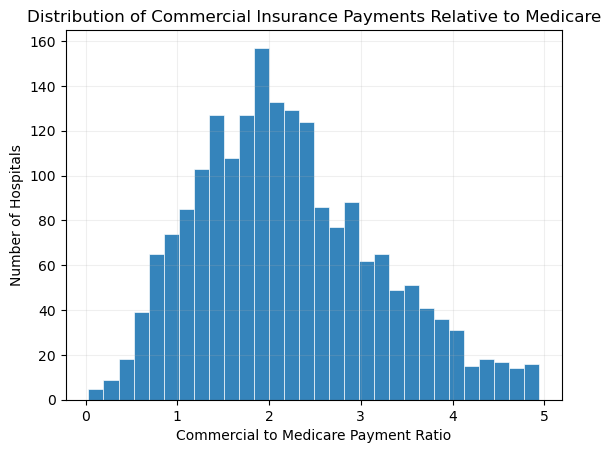

In [41]:
x = df["commercial_to_medicare"].dropna()

plt.figure()
plt.hist(x, bins=30, edgecolor="white", linewidth=0.5, alpha=0.9)
plt.grid(True, alpha=0.20)
plt.xlabel("Commercial to Medicare Payment Ratio")
plt.ylabel("Number of Hospitals")
plt.title("Distribution of Commercial Insurance Payments Relative to Medicare")
plt.show()

### Correlation Matrix of Key Variables

This figure visualizes the pairwise correlations among:
- `rating_num`
- `commercial_to_medicare`
- `charge_to_medicare`
- `ma_to_medicare`

The heatmap confirms that the strongest positive association with hospital rating appears for `commercial_to_medicare`, while `charge_to_medicare` and `ma_to_medicare` show much weaker relationships. The price ratios are also only weakly correlated with one another, suggesting they capture different aspects of hospital pricing rather than a single shared pricing system.

This figure provides a compact visual summary of the same pattern later confirmed by regression: commercial pricing is the price measure most clearly aligned with hospital quality.

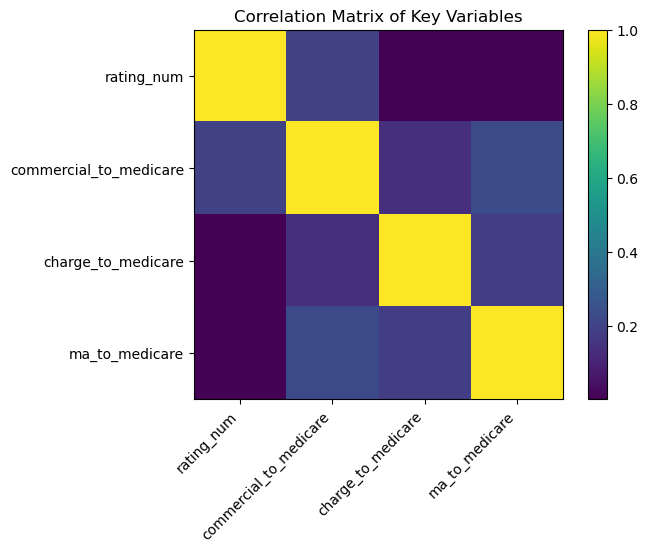

In [42]:
cols=["rating_num","commercial_to_medicare","charge_to_medicare","ma_to_medicare"]
c=df[cols].dropna().corr()

plt.figure()
plt.imshow(c.values)
plt.xticks(range(len(cols)),cols,rotation=45,ha="right")
plt.yticks(range(len(cols)),cols)
plt.colorbar()
plt.title("Correlation Matrix of Key Variables")
plt.show()

### Stability of the Commercial Pricing Coefficient Across OLS Models

This figure compares the estimated coefficient on `commercial_to_medicare` across three OLS specifications:
- baseline OLS
- OLS with charge controls
- OLS with state fixed effects

Each point shows the estimated coefficient, and each horizontal line shows the approximate 95% confidence interval.

The figure shows that the commercial pricing coefficient remains positive and fairly stable across model specifications. Adding charge controls has little effect, and even after adding state fixed effects the estimate remains strong. This is an important robustness result because it shows that the core pricing-quality relationship is not highly sensitive to reasonable changes in model specification.

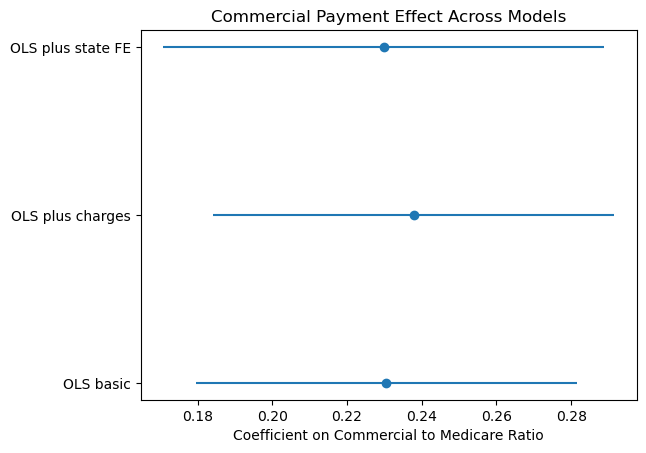

In [43]:
rows=[]
def add(model,label):
    b=model.params["commercial_to_medicare"]
    se=model.bse["commercial_to_medicare"]
    rows.append((label,b,b-1.96*se,b+1.96*se))

add(m1,"OLS basic")
add(m2,"OLS plus charges")
add(m4,"OLS plus state FE")

coef=pd.DataFrame(rows,columns=["model","b","lo","hi"])
ypos=np.arange(coef.shape[0])

plt.figure()
plt.hlines(ypos,coef["lo"],coef["hi"])
plt.plot(coef["b"],ypos,marker="o",linestyle="None")
plt.yticks(ypos,coef["model"])
plt.xlabel("Coefficient on Commercial to Medicare Ratio")
plt.title("Commercial Payment Effect Across Models")
plt.show()

### Probability of High Quality by Commercial Payment Level

This figure groups hospitals into ten bins based on `commercial_to_medicare` and plots the share of hospitals in each bin that are classified as `high_quality` (4–5 stars).

The pattern is clearly upward overall. Hospitals with higher commercial-to-Medicare payment ratios are more likely to be high-quality hospitals. The relationship is not perfectly smooth across all bins, but the general increase is strong and visually consistent with the logistic regression results.

This figure reinforces the main finding from the binary models: higher commercial payment levels are associated not only with higher average ratings, but also with a higher probability of belonging to the top quality group.

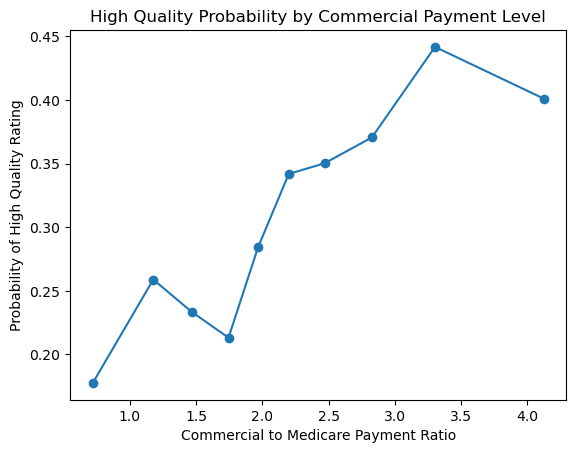

In [44]:
d=df[["commercial_to_medicare","high_quality"]].dropna().copy()
d["bin"]=pd.qcut(d["commercial_to_medicare"],10,duplicates="drop")

b=d.groupby("bin",observed=True).agg(
    mid=("commercial_to_medicare","mean"),
    p_high=("high_quality","mean")
).reset_index(drop=True)

plt.figure()
plt.plot(b["mid"],b["p_high"],marker="o")
plt.xlabel("Commercial to Medicare Payment Ratio")
plt.ylabel("Probability of High Quality Rating")
plt.title("High Quality Probability by Commercial Payment Level")
plt.show()

In [45]:
df.columns

Index(['CCN', 'STATE', 'Tot_Dschrgs_sum', 'rating_num', 'rating_available',
       'charge_to_medicare', 'commercial_to_medicare', 'ma_to_medicare',
       'gap_charge_comm_level', 'gap_charge_comm_ratio', 'has_turquoise',
       'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_State_Abrvtn',
       'Rndrng_Prvdr_RUCA_Desc', 'Hospital Type', 'Hospital Ownership',
       'Emergency Services', 'has_hosp_info',
       'Government - Hospital District or Authority', 'Government - Local',
       'Government - State', 'Physician', 'Proprietary', 'Tribal',
       'Voluntary non-profit - Church', 'Voluntary non-profit - Other',
       'Voluntary non-profit - Private', 'Yes', 'high_quality', 'log_comm'],
      dtype='object')

### Visualize the Charge-to-Commercial Gap and Hospital Quality

This figure groups hospitals into ten bins based on `gap_charge_comm_ratio`, which measures how much larger hospital charges are than negotiated commercial payments. The purpose is to test whether hospitals with a larger markup between charges and actual negotiated payments also tend to have different quality ratings.

The plotted pattern is clearly downward overall. Hospitals with smaller charge-to-commercial gaps tend to have higher average star ratings, while hospitals with larger gaps tend to have lower ratings. This suggests that extreme markup behavior may be associated with lower quality rather than higher quality.

This result is useful because it reinforces the broader pattern in the thesis: price variables tied more closely to actual negotiated payments appear more informative about quality than inflated listed charges.

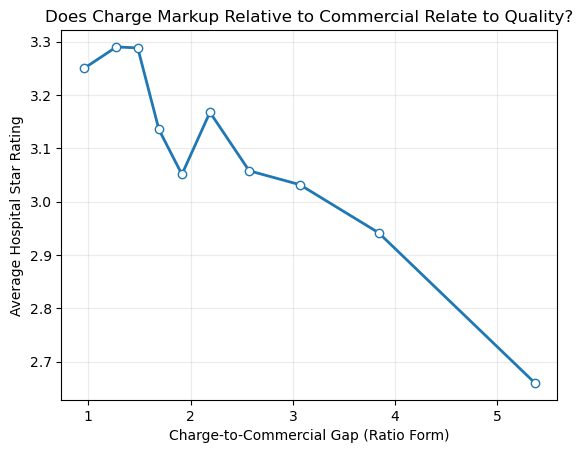

In [46]:
d = df[["gap_charge_comm_ratio","rating_num"]].dropna().copy()
d["bin"] = pd.qcut(d["gap_charge_comm_ratio"], 10, duplicates="drop")

b = d.groupby("bin", observed=True).agg(
    mid=("gap_charge_comm_ratio","mean"),
    mean_rating=("rating_num","mean")
).reset_index(drop=True)

plt.figure()
plt.plot(b["mid"], b["mean_rating"], marker="o", linewidth=2, markerfacecolor="white")
plt.grid(True, alpha=0.25)
plt.xlabel("Charge-to-Commercial Gap (Ratio Form)")
plt.ylabel("Average Hospital Star Rating")
plt.title("Does Charge Markup Relative to Commercial Relate to Quality?")
plt.show()

### Ordinal Logistic Regression for Hospital Star Ratings

This model treats hospital quality as an **ordered outcome** rather than a continuous one. Because hospital ratings run from 1 to 5 stars, an ordinal logistic model is a natural alternative to OLS.

The predictors are:
- `commercial_to_medicare`
- `charge_to_medicare`

The results show:
- `commercial_to_medicare` coefficient = **0.4049**, **p < 0.001**
- `charge_to_medicare` coefficient = **-0.0092**, **p = 0.690**

This confirms the same pattern seen in OLS and logit models: higher commercial payment ratios are strongly associated with better hospital ratings, while charge inflation is not. Using an ordered model strengthens the analysis because it matches the ordinal structure of the star rating variable rather than treating ratings as purely continuous.

In [47]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
d = df[["rating_num", "commercial_to_medicare", "charge_to_medicare"]].dropna().copy()
d["rating_num"] = d["rating_num"].astype(int)

mod_ord = OrderedModel(
    d["rating_num"],
    d[["commercial_to_medicare", "charge_to_medicare"]],
    distr="logit"
)

res_ord = mod_ord.fit(method="bfgs", disp=False)
res_ord.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:             rating_num   Log-Likelihood:                -2294.3
Model:                   OrderedModel   AIC:                             4601.
Method:            Maximum Likelihood   BIC:                             4633.
Date:                Fri, 10 Apr 2026                                         
Time:                        11:44:58                                         
No. Observations:                1583                                         
Df Residuals:                    1577                                         
Df Model:                           2                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
commercial_to_medicare     0.4049      0.048      8.410      0.000       0.311       0.499
charge_to_medicare        -0.0092      0.023     -0.399      0.690      -0.054       0.036
1/2                       -1.7605      0.171    -10.270      0.000      -2.096      -1.425
2/3                        0.5657      0.051     11.027      0.000       0.465       0.666
3/4                        0.3419      0.039      8.731      0.000       0.265       0.419
4/5                        0.5696      0.046     12.441      0.000       0.480       0.659
==========================================================================================
"""

### Ordinal Logistic Regression with State Fixed Effects

This model extends the ordinal logistic specification by adding state fixed effects. The goal is to test whether the relationship between commercial pricing and ordered hospital quality remains after comparing hospitals within the same state.

The results show:
- `commercial_to_medicare` coefficient = **0.4174**, **p < 0.001**
- `charge_to_medicare` coefficient = **-0.0025**, **p = 0.930**

Compared with the ordinal model without state controls, the commercial effect remains highly significant and slightly larger in magnitude, while the charge effect remains completely insignificant. This reinforces the conclusion that the pricing-quality relationship is not just driven by broad geographic differences across states.

In [48]:
d = df[["rating_num", "commercial_to_medicare", "charge_to_medicare", "STATE"]].dropna().copy()
d["rating_num"] = d["rating_num"].astype(int)

state_d = pd.get_dummies(d["STATE"], drop_first=True, dtype=float)
X = pd.concat([d[["commercial_to_medicare", "charge_to_medicare"]], state_d], axis=1)

mod_ord_fe = OrderedModel(
    d["rating_num"],
    X,
    distr="logit"
)

res_ord_fe = mod_ord_fe.fit(method="bfgs", disp=False)
res_ord_fe.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:             rating_num   Log-Likelihood:                -2189.4
Model:                   OrderedModel   AIC:                             4489.
Method:            Maximum Likelihood   BIC:                             4784.
Date:                Fri, 10 Apr 2026                                         
Time:                        11:45:32                                         
No. Observations:                1583                                         
Df Residuals:                    1528                                         
Df Model:                          51                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
commercial_to_medicare     0.4174      0.055      7.648      0.000       0.310       0.524
charge_to_medicare        -0.0025      0.029     -0.088      0.930      -0.059       0.054
AL                        -0.1690      0.935     -0.181      0.857      -2.001       1.663
AR                        -0.3601      0.996     -0.361      0.718      -2.313       1.593
AZ                         0.0042      0.914      0.005      0.996      -1.788       1.796
CA                         0.6970      0.892      0.782      0.434      -1.051       2.445
CO                         1.4585      0.946      1.542      0.123      -0.395       3.312
CT                         0.4669      0.969      0.482      0.630      -1.433       2.366
DC                        -1.5130      1.209     -1.252      0.211      -3.882       0.856
DE                         1.0391      1.416      0.734      0.463      -1.736       3.814
FL                         0.3209      0.898      0.357      0.721      -1.439       2.081
GA                         0.0067      0.930      0.007      0.994      -1.816       1.829
HI                         0.8743      1.048      0.834      0.404      -1.179       2.928
IA                         0.4149      0.967      0.429      0.668      -1.480       2.310
ID                         1.8051      1.073      1.682      0.093      -0.298       3.909
IL                         0.0212      0.910      0.023      0.981      -1.762       1.804
IN                         0.3719      0.907      0.410      0.682      -1.406       2.150
KS                         1.5481      0.971      1.594      0.111      -0.356       3.452
KY                        -0.2299      0.922     -0.249      0.803      -2.036       1.576
LA                         0.4172      0.935      0.446      0.655      -1.415       2.250
MA                         0.0788      0.947      0.083      0.934      -1.778       1.936
ME                        -0.8715      1.803     -0.483      0.629      -4.404       2.661
MI                         0.4881      0.915      0.533      0.594      -1.306       2.282
MN                         1.9763      0.929      2.128      0.033       0.156       3.797
MO                         1.3955      0.930      1.501      0.133      -0.427       3.218
MS                        -0.6859      0.960     -0.715      0.475      -2.567       1.195
MT                         0.4644      1.326      0.350      0.726      -2.134       3.063
NC                         0.2961      0.910      0.325      0.745      -1.488       2.080
ND                         1.4018      1.241      1.129      0.259      -1.031       3.834
NE                         0.6676      1.001      0.667      0.505      -1.294       2.629
NH                         1.2511      1.057      1.183      0.237      -0.821       3.323
NJ                        -0.0140      0.922     -0.015      0.988  

### Pull County-Level Socioeconomic Data from the Census API

This step retrieves county-level socioeconomic data from the 2022 ACS 5-year Census API. The variables requested are:
- county name
- median household income
- poverty count
- total population

A poverty rate is then constructed as `poverty_count / population`.

The resulting table provides county-level context that can later be used to test whether hospital pricing or quality relationships are partly explained by local socioeconomic conditions. This is an expansion step rather than a core result, but it prepares the project for richer controls beyond hospital-level pricing variables alone.

In [49]:
import requests
import pandas as pd

API_KEY = "af8ee95df85a6ef673beb499141f55788036a1eb"

url = f"https://api.census.gov/data/2022/acs/acs5?get=NAME,B19013_001E,B17001_002E,B01003_001E&for=county:*&in=state:*&key={API_KEY}"

res = requests.get(url)
data = res.json()

df_acs = pd.DataFrame(data[1:], columns=data[0])

df_acs.columns = [
    "name",
    "median_income",
    "poverty_count",
    "population",
    "county",
    "state"
]

df_acs["median_income"] = pd.to_numeric(df_acs["median_income"])
df_acs["poverty_count"] = pd.to_numeric(df_acs["poverty_count"])
df_acs["population"] = pd.to_numeric(df_acs["population"])

df_acs["poverty_rate"] = df_acs["poverty_count"] / df_acs["population"]

df_acs.head()

,name,median_income,poverty_count,population,county,state,poverty_rate
0,"Autauga County, Alabama",68315,6630,58761,01,001,0.112830
1,"Baldwin County, Alabama",71039,23445,233420,01,003,0.100441
2,"Barbour County, Alabama",39712,5280,24877,01,005,0.212244
3,"Bibb County, Alabama",50669,4297,22251,01,007,0.193115
4,"Blount County, Alabama",57440,8277,59077,01,009,0.140105


### Create a Reduced Cost Report Covariate File

This step keeps a focused subset of cost report variables that are most relevant for hospital structure, finances, and payment environment. These include:
- geography and market variables
- hospital capacity measures
- staffing and residency counts
- total costs and revenues
- uncompensated care measures
- DSH and IME indicators
- cost-to-charge ratio

The code also standardizes the hospital identifier by converting `Provider CCN` into a zero-padded six-digit `CCN`, making it compatible with the main hospital-level dataset. Numeric conversion is applied to all non-identifier fields.

The output shows:
- reduced file shape = **6,103 rows × 20 columns**
- **6,040 unique CCNs**

This means the cost report file contains broad hospital coverage and is already close to merge-ready. It provides a useful future source of controls for hospital capacity, teaching intensity, financial position, and uncompensated care burden.

In [50]:
cost = pd.read_csv(r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Covariates\CostReport_2023_Final.csv", low_memory=False)

print(cost.shape)
print(cost.columns.tolist())
print(cost.head())

(6103, 117)
['rpt_rec_num', 'Provider CCN', 'Hospital Name', 'Street Address', 'City', 'State Code', 'Zip Code', 'County', 'Medicare CBSA Number', 'Rural Versus Urban', 'CCN Facility Type', 'Provider Type', 'Type of Control', 'Fiscal Year Begin Date', 'Fiscal Year End Date', 'FTE - Employees on Payroll', 'Number of Interns and Residents (FTE)', 'Total Days Title V', 'Total Days Title XVIII', 'Total Days Title XIX', 'Total Days (V + XVIII + XIX + Unknown)', 'Number of Beds', 'Total Bed Days Available', 'Total Discharges Title V', 'Total Discharges Title XVIII', 'Total Discharges Title XIX', 'Total Discharges (V + XVIII + XIX + Unknown)', 'Number of Beds + Total for all Subproviders', 'Hospital Total Days Title V For Adults & Peds', 'Hospital Total Days Title XVIII For Adults & Peds', 'Hospital Total Days Title XIX For Adults & Peds', 'Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds', 'Hospital Number of Beds For Adults & Peds', 'Hospital Total Bed Days Available For Ad

### Inspect the Hospital-Level Wage File

This step loads the hospital-level CMS wage index file and inspects its structure. The purpose is to identify variables that capture internal hospital labor costs and staffing wage conditions.

The output shows:
- **3,066 rows**
- hospital-level fields such as:
  - `PROV`
  - `prov unadjusted AHW`
  - `prov occmix adjusted ahw`

These variables are useful because they capture provider-specific wage conditions and occupational mix adjustments. In later models, these hospital-level wage measures serve as a mechanism proxy for staffing investment.

In [51]:
cost = pd.read_csv(r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Covariates\CostReport_2023_Final.csv", low_memory=False)

keep = [
    "Provider CCN",
    "Hospital Name",
    "State Code",
    "County",
    "Zip Code",
    "Medicare CBSA Number",
    "Rural Versus Urban",
    "Number of Beds",
    "FTE - Employees on Payroll",
    "Number of Interns and Residents (FTE)",
    "Total Costs",
    "Total Patient Revenue",
    "Net Patient Revenue",
    "Net Income",
    "Cost of Charity Care",
    "Cost of Uncompensated Care",
    "Total Unreimbursed and Uncompensated Care",
    "Allowable DSH Percentage",
    "Total IME Payment",
    "Cost To Charge Ratio"
]

cost_small = cost[keep].copy()

cost_small["Provider CCN"] = (
    cost_small["Provider CCN"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(6)
)

cost_small = cost_small.rename(columns={"Provider CCN": "CCN"})

for c in cost_small.columns:
    if c not in ["CCN", "Hospital Name", "State Code", "County", "Zip Code", "Rural Versus Urban"]:
        cost_small[c] = pd.to_numeric(cost_small[c], errors="coerce")

print(cost_small.shape)
print(cost_small["CCN"].nunique())
print(cost_small.head())

(6103, 20)
6040
      CCN                         Hospital Name State Code  County  \
0  110130                 IRWIN COUNTY HOSPITAL         GA   IRWIN   
1  144042              LAKE BEHAVIORAL HOSPITAL         IL    LAKE   
2  043036  EVEREST REHABILITATION HOSPITAL BENT         AR  BENTON   
3  454155  OCEANS BEHAVIORAL HOSPITAL CORPUS CH         TX  NUECES   
4  144043   MONTROSE BEHAVIORAL HEALTH HOSPITAL         IL     NaN   

     Zip Code  Medicare CBSA Number Rural Versus Urban  Number of Beds  \
0       31774               99911.0                  R            34.0   
1       60085               29404.0                  U           161.0   
2  72758-1347               22220.0                  U            36.0   
3       78404               18580.0                  U            42.0   
4  60640-5122                   NaN                NaN             NaN   

   FTE - Employees on Payroll  Number of Interns and Residents (FTE)  \
0                       97.15                 

### Inspect the Area-Level Wage Index File

This step loads the provider-area wage file and inspects its structure. The purpose is to identify variables that capture the broader regional wage environment around each hospital.

The output shows:
- **3,066 rows**
- variables including:
  - provider identifier
  - CBSA code
  - provider occupational-mix adjusted hourly wage
  - CBSA occupational-mix adjusted wage
  - CBSA occupational-mix wage index

This file complements the hospital-level wage file by separating internal hospital wage structure from external regional labor-market conditions. In later regression models, this distinction is important because hospital-level staffing wages were found to matter for quality, while the broader CBSA wage index was not.

In [52]:
wage = pd.read_excel(r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Covariates\fy-2026-final-rule-wage-index-pufs\2. FY26.Final_Rule_PUF.20250725.provoccmix_Results.xlsx")

print(wage.shape)
print(wage.columns.tolist())
print(wage.head())

(3066, 12)
['PROV', 'FROM', 'TO', 'CBSAGEO', 'prov unadjusted\nwages', 'prov hours', 'prov\nunadjusted\nAHW', 'prov occ mix wages', 'prov\nnurse\noccmix\nfactor', 'CBSAGEO\nnurse\noccmix\nfactor', 'prov\noccmix\nadjusted\nahw', 'Pct Diff\n(prov\noccmix\nadjusted\nahw - prov\nunadj\nahw)/(prov\nunadj ahw)']
     PROV        FROM          TO  CBSAGEO  prov unadjusted\nwages  \
0  010001  20220101.0  20221231.0    20020            1.779840e+08   
1  010005  20211226.0  20221224.0        1            7.447779e+07   
2  010006  20220101.0  20221231.0    22520            7.036022e+07   
3  010007  20211219.0  20221217.0        1            1.148484e+07   
4  010008  20220101.0  20221231.0        1            5.048740e+06   

   prov hours  prov\nunadjusted\nAHW  prov occ mix wages  \
0     4320930                  41.19        1.786606e+08   
1     2041169                  36.49        7.424770e+07   
2     1856372                  37.90        7.038191e+07   
3      385790                  

c:\Users\priva\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


### Inspect the Area-Level Wage Index File

This step loads the provider-area wage file and inspects its structure. The purpose is to identify variables that capture the broader regional wage environment around each hospital.

The output shows:
- **3,066 rows**
- variables including:
  - provider identifier
  - CBSA code
  - provider occupational-mix adjusted hourly wage
  - CBSA occupational-mix adjusted wage
  - CBSA occupational-mix wage index

This file complements the hospital-level wage file by separating internal hospital wage structure from external regional labor-market conditions. In later regression models, this distinction is important because hospital-level staffing wages were found to matter for quality, while the broader CBSA wage index was not.

In [53]:
wage4 = pd.read_excel(r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Covariates\fy-2026-final-rule-wage-index-pufs\4. FY26.Final_Rule_PUF.20250725.AHW_by_Provider_Area_Listing_Results.xlsx")

print(wage4.shape)
print(wage4.columns.tolist())
print(wage4.head())

(3066, 10)
['PROV', 'CBSAGEO', '# of\nprovs in\nCBSAGEO', 'prov occmix\nwages', 'prov hour', 'prov\noccmix\nahw', 'CBSAGEO occmix\nwages', 'CBSAGEO\nhour', 'CBSAGEO\noccmix\nahw', 'CBSAGEO\noccmix\nwage\nindex']
     PROV  CBSAGEO  # of\nprovs in\nCBSAGEO  prov occmix\nwages  prov hour  \
0  010001    20020                        3        1.786606e+08    4320930   
1  010005        1                       33        7.424770e+07    2041169   
2  010006    22520                        3        7.038191e+07    1856372   
3  010007        1                       33        1.177637e+07     385790   
4  010008        1                       33        5.250913e+06     169304   

   prov\noccmix\nahw  CBSAGEO occmix\nwages  CBSAGEO\nhour  \
0              41.35           2.908471e+08        7017035   
1              36.38           5.313080e+08       14368122   
2              37.91           1.481878e+08        3739557   
3              30.53           5.313080e+08       14368122   
4        

c:\Users\priva\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


### Merge Hospital-Level Wage Measures into the Analysis File

This step merges provider-level wage data into the hospital-level dataset using the standardized hospital identifier (`CCN` in the main file and `PROV` in the wage file).

Only the key wage columns are kept:
- occupational-mix adjusted hourly wage
- unadjusted hourly wage

The output shows that the merged file retains **3,369 hospitals**, and the missingness rate for the wage variables is about **13.36%**. This means wage coverage is fairly strong, though not complete, and the merged dataset is usable for mechanism testing. :contentReference[oaicite:0]{index=0}

In [54]:
# convert both to string and pad
df["CCN"] = df["CCN"].astype(str).str.zfill(6)
wage["PROV"] = wage["PROV"].astype(str).str.zfill(6)

In [55]:
wage_small = wage[[
    "PROV",
    "prov\noccmix\nadjusted\nahw",
    "prov\nunadjusted\nAHW"
]].copy()

merged = df.merge(
    wage_small,
    left_on="CCN",
    right_on="PROV",
    how="left"
)

In [56]:
print(merged.shape)
print(merged["prov\noccmix\nadjusted\nahw"].isna().mean())

(3369, 33)
0.13357079252003562


### Test Whether Hospital-Level Wage Investment Helps Explain Quality

This model regresses `rating_num` on:
- `commercial_to_medicare`
- `charge_to_medicare`
- `prov_occmix_ahw`

The goal is to test whether hospital-level staffing wages help explain quality differences and whether the commercial-pricing effect persists after adding this mechanism proxy.

The results show:
- `commercial_to_medicare` coefficient = **0.2292**, **p < 0.001**
- `charge_to_medicare` coefficient = **-0.0122**, **p = 0.373**
- `prov_occmix_ahw` coefficient = **0.0101**, **p < 0.001**
- **R² = 0.057**

This suggests that hospitals with higher staffing wage levels tend to have higher quality ratings, while commercial pricing remains strongly associated with quality and charges remain insignificant. The modest rise in R² relative to the simplest baseline indicates that staffing wages capture a real but limited part of the quality relationship.

In [57]:
import statsmodels.formula.api as smf

merged = merged.rename(columns={
    "prov\noccmix\nadjusted\nahw": "prov_occmix_ahw",
    "prov\nunadjusted\nAHW": "prov_unadj_ahw"
})

model = smf.ols(
    "rating_num ~ commercial_to_medicare + charge_to_medicare + prov_occmix_ahw",
    data=merged
).fit(cov_type="HC1")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             rating_num   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     35.47
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           3.53e-22
Time:                        11:45:36   Log-Likelihood:                -2301.1
No. Observations:                1570   AIC:                             4610.
Df Residuals:                    1566   BIC:                             4632.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

### Merge Both Hospital-Level and Area-Level Wage Variables

This step loads both CMS wage files:
- the hospital-level wage file
- the provider-area wage index file

The columns are renamed into cleaner variable names, identifiers are standardized, and then both files are merged into the hospital-level analysis dataset. The purpose is to distinguish between:
- **internal hospital wage investment** (`prov_occmix_ahw`)
- **external regional wage pressure** (`cbsa_wage_index`)

The output preview confirms that the merge worked correctly, and missingness for both wage variables is about **13.36%** in this version of the merged file. This creates a dataset suitable for testing whether quality is more closely tied to hospital-level staffing investment or to the surrounding labor-cost environment.

In [58]:
wage_hosp = pd.read_excel(
    r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Covariates\fy-2026-final-rule-wage-index-pufs\2. FY26.Final_Rule_PUF.20250725.provoccmix_Results.xlsx"
)

wage_area = pd.read_excel(
    r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Covariates\fy-2026-final-rule-wage-index-pufs\4. FY26.Final_Rule_PUF.20250725.AHW_by_Provider_Area_Listing_Results.xlsx"
)

wage_hosp = wage_hosp.rename(columns={
    "prov\noccmix\nadjusted\nahw": "prov_occmix_ahw",
    "prov\nunadjusted\nAHW": "prov_unadj_ahw"
})

wage_area = wage_area.rename(columns={
    "prov\noccmix\nahw": "prov_occmix_ahw_areafile",
    "CBSAGEO\noccmix\nwage\nindex": "cbsa_wage_index"
})

wage_hosp["PROV"] = wage_hosp["PROV"].astype(str).str.zfill(6)
wage_area["PROV"] = wage_area["PROV"].astype(str).str.zfill(6)
df["CCN"] = df["CCN"].astype(str).str.zfill(6)

wage_hosp_small = wage_hosp[[
    "PROV",
    "prov_occmix_ahw",
    "prov_unadj_ahw"
]].copy()

wage_area_small = wage_area[[
    "PROV",
    "cbsa_wage_index"
]].copy()

merged = df.merge(
    wage_hosp_small,
    left_on="CCN",
    right_on="PROV",
    how="left"
)

merged = merged.merge(
    wage_area_small,
    left_on="CCN",
    right_on="PROV",
    how="left",
    suffixes=("", "_area")
)

print(merged[["CCN", "prov_occmix_ahw", "cbsa_wage_index"]].head())
print(merged[["prov_occmix_ahw", "cbsa_wage_index"]].isna().mean())

c:\Users\priva\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


      CCN  prov_occmix_ahw  cbsa_wage_index
0  010001            41.35           0.7164
1  010005            36.38           0.6391
2  010006            37.91           0.6849
3  010007            30.53           0.6391
4  010008            31.01           0.6391
prov_occmix_ahw    0.133571
cbsa_wage_index    0.133571
dtype: float64


c:\Users\priva\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


### Add Hospital and Regional Wage Measures to the Quality Model

This model regresses `rating_num` on:
- `commercial_to_medicare`
- `charge_to_medicare`
- `prov_occmix_ahw`
- `cbsa_wage_index`

The purpose is to test whether hospital quality is associated with internal staffing wages, broader regional wage levels, or both.

The results show:
- `commercial_to_medicare` coefficient = **0.2218**, **p < 0.001**
- `charge_to_medicare` coefficient = **-0.0069**, **p = 0.610**
- `prov_occmix_ahw` coefficient = **0.0250**, **p < 0.001**
- `cbsa_wage_index` coefficient = **-1.1696**, **p < 0.001**
- **R² = 0.066**

This model shows that staffing wage investment remains strongly and positively associated with quality, while charges remain uninformative. In this no-state-FE version, the regional wage index is significantly negative, suggesting that hospitals in higher-cost labor markets may face downward pressure on measured quality after holding the other variables constant.

In [59]:
reg_df = merged[[
    "rating_num",
    "commercial_to_medicare",
    "charge_to_medicare",
    "prov_occmix_ahw",
    "cbsa_wage_index"
]].dropna()

model = smf.ols(
    "rating_num ~ commercial_to_medicare + charge_to_medicare + prov_occmix_ahw + cbsa_wage_index",
    data=reg_df
).fit(cov_type="HC1")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             rating_num   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     30.94
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           7.99e-25
Time:                        11:45:38   Log-Likelihood:                -2293.1
No. Observations:                1570   AIC:                             4596.
Df Residuals:                    1565   BIC:                             4623.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

### Create a Clean Wage-Augmented Analysis File

This step rebuilds the merge between the cleaned hospital-level analysis file and the two CMS wage files, then performs a quality-assurance check and saves the result as `analysis_hospital_level_clean_with_wages.csv`.

The output shows:
- merged shape = **1,702 rows × 21 columns**
- missingness for `prov_occmix_ahw`, `prov_unadj_ahw`, and `cbsa_wage_index` is only **0.76%**
- the preview confirms that wage variables now align correctly to each hospital

This is a major improvement over the earlier merge attempt because it produces a nearly complete modeling file with both hospital-level and area-level wage variables attached. That makes it appropriate for the final mechanism analysis. :contentReference[oaicite:1]{index=1}

### Quartile-Based Nonlinear Model

This model replaces the continuous commercial-pricing variable with quartile indicators in order to test whether higher pricing tiers are associated with discrete jumps in quality:

`rating_num ~ price_q_1 + price_q_2 + price_q_3 + charge_to_medicare + C(STATE)`

The results show:
- Quartile 2 effect = **0.1516**, p = 0.044
- Quartile 3 effect = **0.3236**, p < 0.001
- Quartile 4 effect = **0.5337**, p < 0.001
- `charge_to_medicare` = **0.0043**, p = 0.787
- R² = **0.158**

This indicates a tiered relationship: hospitals in higher commercial-pricing quartiles have systematically higher quality ratings than those in the lowest quartile. The pattern grows stronger across the upper tiers, which suggests that the nonlinear structure is better described as stratification across hospital pricing tiers rather than by a smooth curve. :contentReference[oaicite:3]{index=3}

In [60]:
import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv(r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\analysis_hospital_level_clean.csv")

# create quartiles
df = df[df["commercial_to_medicare"].notna()]
df["price_q"] = pd.qcut(df["commercial_to_medicare"], 4, labels=False)

# make dummies
df = pd.get_dummies(df, columns=["price_q"], drop_first=True)

model = smf.ols(
    "rating_num ~ price_q_1 + price_q_2 + price_q_3 + charge_to_medicare + C(STATE)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             rating_num   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     5.395
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           3.27e-30
Time:                        11:45:38   Log-Likelihood:                -2232.3
No. Observations:                1583   AIC:                             4573.
Df Residuals:                    1529   BIC:                             4862.
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.5196      0

### Mechanism Models with State Fixed Effects

These three models test whether staffing wages help explain part of the relationship between commercial pricing and hospital quality while holding state differences constant.

Model 1 estimates:
`rating_num ~ commercial_to_medicare + charge_to_medicare + C(STATE)`

Model 2 adds hospital-level staffing wages:
`rating_num ~ commercial_to_medicare + prov_occmix_ahw + charge_to_medicare + C(STATE)`

Model 3 treats staffing wages as the outcome:
`prov_occmix_ahw ~ commercial_to_medicare + C(STATE)`

The key results are:

- Model 1:
  - `commercial_to_medicare` = **0.2305**, p < 0.001
  - `charge_to_medicare` = **0.0040**, p = 0.798
  - R² = **0.163**

- Model 2:
  - `commercial_to_medicare` = **0.2014**, p < 0.001
  - `prov_occmix_ahw` = **0.0222**, p < 0.001
  - `charge_to_medicare` = **-0.0029**, p = 0.853
  - R² = **0.190**

- Model 3:
  - `commercial_to_medicare` = **1.3671**, p < 0.001
  - R² = **0.536**

Taken together, these models support a partial mechanism story. Commercial pricing remains strongly associated with hospital quality after state fixed effects, but its coefficient declines once staffing wages are added. At the same time, commercial pricing strongly predicts staffing wages. This is consistent with the interpretation that part of the commercial-pricing effect may operate through hospital labor investment. :contentReference[oaicite:0]{index=0}

In [61]:
state_disp = df.groupby("STATE")["commercial_to_medicare"].std().rename("state_dispersion")

df = df.merge(state_disp, on="STATE", how="left")

model = smf.ols(
    "rating_num ~ commercial_to_medicare + state_dispersion + charge_to_medicare + C(STATE)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             rating_num   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     6.013
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.66e-33
Time:                        11:45:38   Log-Likelihood:                -2224.7
No. Observations:                1582   AIC:                             4551.
Df Residuals:                    1531   BIC:                             4825.
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

### Add Regional Wage Index to the State Fixed-Effects Mechanism Model

This model extends the staffing mechanism specification by adding the CBSA wage index:

`rating_num ~ commercial_to_medicare + prov_occmix_ahw + cbsa_wage_index + charge_to_medicare + C(STATE)`

The goal is to separate internal hospital wage investment from the broader regional labor-cost environment.

The results show:
- `commercial_to_medicare` = **0.2011**, p < 0.001
- `prov_occmix_ahw` = **0.0231**, p < 0.001
- `cbsa_wage_index` = **-0.1126**, p = 0.748
- `charge_to_medicare` = **-0.0022**, p = 0.890
- R² = **0.190**

Once state fixed effects are included, the regional wage index is not statistically significant, while hospital-level staffing wages remain strongly positive. This suggests that the relevant mechanism is internal hospital labor investment rather than the general wage environment of the surrounding area. :contentReference[oaicite:1]{index=1}

In [62]:
import pandas as pd

# --- load files ---
df = pd.read_csv(
    r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\analysis_hospital_level_clean.csv"
)

wage_hosp = pd.read_excel(
    r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Covariates\fy-2026-final-rule-wage-index-pufs\2. FY26.Final_Rule_PUF.20250725.provoccmix_Results.xlsx"
)

wage_area = pd.read_excel(
    r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Covariates\fy-2026-final-rule-wage-index-pufs\4. FY26.Final_Rule_PUF.20250725.AHW_by_Provider_Area_Listing_Results.xlsx"
)

# --- clean column names ---
wage_hosp = wage_hosp.rename(columns={
    "prov\noccmix\nadjusted\nahw": "prov_occmix_ahw",
    "prov\nunadjusted\nAHW": "prov_unadj_ahw"
})

wage_area = wage_area.rename(columns={
    "prov\noccmix\nahw": "prov_occmix_ahw_areafile",
    "CBSAGEO\noccmix\nwage\nindex": "cbsa_wage_index"
})
# --- standardize merge keys ---
wage_hosp["PROV"] = wage_hosp["PROV"].astype(str).str.zfill(6)
wage_area["PROV"] = wage_area["PROV"].astype(str).str.zfill(6)
df["CCN"] = df["CCN"].astype(str).str.zfill(6)

# --- keep only needed columns ---
wage_hosp_small = wage_hosp[[
    "PROV",
    "prov_occmix_ahw",
    "prov_unadj_ahw"
]].copy()

wage_area_small = wage_area[[
    "PROV",
    "cbsa_wage_index"
]].copy()

# --- merge hospital-level wages ---
merged = df.merge(
    wage_hosp_small,
    left_on="CCN",
    right_on="PROV",
    how="left"
).drop(columns=["PROV"], errors="ignore")

# --- merge area-level wage index ---
merged = merged.merge(
    wage_area_small,
    left_on="CCN",
    right_on="PROV",
    how="left"
).drop(columns=["PROV"], errors="ignore")

# --- quick QA ---
print("Merged shape:", merged.shape)
print("\nMissingness:")
print(merged[["prov_occmix_ahw", "prov_unadj_ahw", "cbsa_wage_index"]].isna().mean())

print("\nPreview:")
print(merged[[
    "CCN",
    "commercial_to_medicare",
    "charge_to_medicare",
    "rating_num",
    "prov_occmix_ahw",
    "prov_unadj_ahw",
    "cbsa_wage_index"
]].head())

# --- save ---
out_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\analysis_hospital_level_clean_with_wages.csv"
merged.to_csv(out_path, index=False)
print(f"\nSaved to: {out_path}")

c:\Users\priva\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


Merged shape: (1702, 21)

Missingness:
prov_occmix_ahw    0.007638
prov_unadj_ahw     0.007638
cbsa_wage_index    0.007638
dtype: float64

Preview:
      CCN  commercial_to_medicare  charge_to_medicare  rating_num  \
0  010001                1.264170            5.253832         4.0   
1  010005                1.966559            2.875165         3.0   
2  010007                1.498830            2.363624         1.0   
3  010011                0.563540            5.402956         2.0   
4  010016                1.374738            8.255952         2.0   

   prov_occmix_ahw  prov_unadj_ahw  cbsa_wage_index  
0            41.35           41.19           0.7164  
1            36.38           36.49           0.6391  
2            30.53           29.77           0.6391  
3            54.95           53.38           0.8476  
4            42.00           43.13           0.8476  

Saved to: C:\Users\priva\OneDrive\Documents\Honors Project\Data\analysis_hospital_level_clean_with_wages.csv


c:\Users\priva\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


### Log-Transformed Nonlinear Check

This model tests whether the pricing-quality relationship remains stable when commercial and charge variables are transformed into logs:

`rating_num ~ log_comm + log_charge + C(STATE)`

The purpose is to reduce skew and check whether the main result depends on extreme values in the original ratio variables.

The results show:
- `log_comm` = **0.4025**, p < 0.001
- `log_charge` = **0.0893**, p = 0.245
- R² = **0.163**

The positive commercial-pricing effect remains strong after log transformation, while the charge ratio remains insignificant. This suggests the commercial-quality relationship is robust to scale transformation and is not being driven by a small number of extreme high-price hospitals. :contentReference[oaicite:2]{index=2}

In [63]:
import statsmodels.formula.api as smf

reg_df = merged.dropna(subset=[
    "rating_num", "commercial_to_medicare", "charge_to_medicare", "prov_occmix_ahw"
]).copy()

m1 = smf.ols(
    "rating_num ~ commercial_to_medicare + charge_to_medicare + C(STATE)",
    data=reg_df
).fit()

m2 = smf.ols(
    "rating_num ~ commercial_to_medicare + prov_occmix_ahw + charge_to_medicare + C(STATE)",
    data=reg_df
).fit()

m3 = smf.ols(
    "prov_occmix_ahw ~ commercial_to_medicare + C(STATE)",
    data=reg_df
).fit()

print("\nMODEL 1")
print(m1.summary())

print("\nMODEL 2")
print(m2.summary())

print("\nMODEL 3")
print(m3.summary())


MODEL 1
                            OLS Regression Results                            
Dep. Variable:             rating_num   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     5.811
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.86e-32
Time:                        11:45:41   Log-Likelihood:                -2207.0
No. Observations:                1570   AIC:                             4518.
Df Residuals:                    1518   BIC:                             4797.
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept          

In [64]:
m4 = smf.ols(
    "rating_num ~ commercial_to_medicare + prov_occmix_ahw + cbsa_wage_index + charge_to_medicare + C(STATE)",
    data=reg_df
).fit()
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:             rating_num   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.161
Method:                 Least Squares   F-statistic:                     6.696
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.38e-40
Time:                        11:45:41   Log-Likelihood:                -2181.9
No. Observations:                1570   AIC:                             4472.
Df Residuals:                    1516   BIC:                             4761.
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

### Log-Transformed Nonlinear Check

This model tests whether the pricing-quality relationship remains stable when commercial and charge variables are transformed into logs:

`rating_num ~ log_comm + log_charge + C(STATE)`

The purpose is to reduce skew and check whether the main result depends on extreme values in the original ratio variables.

The results show:
- `log_comm` = **0.4025**, p < 0.001
- `log_charge` = **0.0893**, p = 0.245
- R² = **0.163**

The positive commercial-pricing effect remains strong after log transformation, while the charge ratio remains insignificant. This suggests the commercial-quality relationship is robust to scale transformation and is not being driven by a small number of extreme high-price hospitals. :contentReference[oaicite:2]{index=2}

In [65]:
import numpy as np

df["log_comm"] = np.log(df["commercial_to_medicare"])
df["log_charge"] = np.log(df["charge_to_medicare"])

model = smf.ols(
    "rating_num ~ log_comm + log_charge + C(STATE)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             rating_num   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     5.826
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.32e-32
Time:                        11:45:41   Log-Likelihood:                -2227.6
No. Observations:                1583   AIC:                             4559.
Df Residuals:                    1531   BIC:                             4838.
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.3683      0.461      5.

### Quadratic Nonlinear Check

This model adds a squared term for commercial pricing to test for smooth curvature:

`rating_num ~ commercial_to_medicare + comm_sq + C(STATE)`

The goal is to determine whether the relationship is convex, concave, or approximately linear over the observed range.

The results show:
- `commercial_to_medicare` = **0.2664**, p = 0.018
- `comm_sq` = **-0.0063**, p = 0.776
- R² = **0.168**

The squared term is not statistically significant, so there is no strong evidence of a smooth quadratic relationship. The commercial-pricing effect remains positive, but the main nonlinear structure appears to be tiered grouping rather than formal polynomial curvature. :contentReference[oaicite:5]{index=5}

In [66]:
df["comm_sq"] = df["commercial_to_medicare"] ** 2

model = smf.ols(
    "rating_num ~ commercial_to_medicare + comm_sq + C(STATE)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             rating_num   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     6.550
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.51e-38
Time:                        11:45:41   Log-Likelihood:                -2399.1
No. Observations:                1702   AIC:                             4902.
Df Residuals:                    1650   BIC:                             5185.
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

### Piecewise Linear Nonlinear Check

This model splits commercial pricing at the sample median into two components:
- `low_comm`
- `high_comm`

The specification is:
`rating_num ~ low_comm + high_comm + C(STATE)`

The purpose is to test whether the effect of commercial pricing differs below versus above the median.

The results show:
- `low_comm` = **0.2706**, p < 0.001
- `high_comm` = **0.2129**, p < 0.001
- R² = **0.169**

Both segments are significant and positive. The coefficient is somewhat larger below the median than above it, suggesting mild diminishing returns, but not a dramatic threshold effect. This reinforces the conclusion that the relationship is broadly monotonic and positive, with the clearest nonlinear structure appearing in grouped or tiered comparisons rather than in a sharp regime shift. 

In [67]:
median_val = df["commercial_to_medicare"].median()

df["low_comm"] = np.minimum(df["commercial_to_medicare"], median_val)
df["high_comm"] = np.maximum(df["commercial_to_medicare"] - median_val, 0)

model = smf.ols(
    "rating_num ~ low_comm + high_comm + C(STATE)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             rating_num   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     6.557
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.34e-38
Time:                        11:45:41   Log-Likelihood:                -2398.9
No. Observations:                1702   AIC:                             4902.
Df Residuals:                    1650   BIC:                             5185.
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.2104      0.467      4.